# VLASOV EQUATION: Kinetic Plasma Dynamics 
### Physics II — BSDSBA 2028 | Theory Notebook
#### Authors: Bautista, Fernando, Rosales, Santhosh, Tiukinhoy, Vocal

---
## Contents

0. [[Section 0 — Define the medium / physical context]](#0)
1. [[Section 1 — Introduce the fundamental statistical object]](#1)
2. [[Section 2 — First-principles microscopic reduction]](#2)
3. [[Section 3 — Key geometric / conservation theorem]](#3)
4. [[Section 4 — Self-consistent governing system]](#4)
5. [[Section 5 — Linearisation]](#5)
6. [[Section 6 — Derive the central physical phenomenon]](#6)
7. [[Section 7 — Bridge to numerical simulation]](#7)

In [2]:
# ── Dependencies ───────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

# Ensure the plot displays correctly in a notebook environment
%matplotlib inline


# Physical constants
eps0 = 8.8541878128e-12   # vacuum permittivity, F m^{-1}
kB = 1.380649e-23         # Boltzmann constant, J K^{-1}
e = 1.602176634e-19       # elementary charge, C
me = 9.1093837015e-31     # electron mass, kg

plt.rcParams.update({
    "figure.dpi": 140,
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
})


print("Environment ready.")

Environment ready.


---
<a id='0'></a>
## 0. The Plasma Medium and the Ordering Behind the Vlasov Model

The Vlasov equation describes a weakly coupled plasma in the mean-field limit. The applicability of the Vlasov model is more restrictive than the generic classification of an ionized gas. A gas may contain free charges yet remain outside the plasma regime when collisions with neutrals or short-range binary encounters dominate the dynamics. The essential distinction is collective response: a charge displacement modifies the electric field, and the resulting field acts on many particles before isolated collisions can relax the perturbation.

The electrostatic component of this collective response is determined by Gauss’s law. For an electron-ion plasma with singly charged ions, the charge density is

$$
\rho(\mathbf r,t)=e n_i(\mathbf r,t)-e n_e(\mathbf r,t),
$$

where $e>0$ is the magnitude of the electron charge, $n_i$ is the ion number density, and $n_e$ is the electron number density. The electric potential satisfies

$$
\nabla^2\phi(\mathbf r,t)=-\frac{\rho(\mathbf r,t)}{\varepsilon_0},
\qquad 
\mathbf E=-\nabla \phi .
$$

A homogeneous plasma satisfying  $n_e=n_i=n_0$ produces no macroscopic electric field. Quasineutrality is a necessary equilibrium condition; in the absence of a compensating positive background, an electron cloud carries net space charge, generates a macroscopic self-field, and does not support a spatially uniform reference state about which small electrostatic oscillations may be consistently linearized.

With the reference state specified, the next step is to determine how the electron density changes when that equilibrium is weakly perturbed by an electrostatic potential.

The first intrinsic electrostatic scale is obtained from the linearized shielding problem. Treat the ions as stationary on the electron response timescale, set $n_i=n_0$, and perturb the electrons by a small electrostatic potential $\phi$. For a thermalized electron population at temperature $T_e$, the electron density follows the Boltzmann factor associated with electron potential energy $-e\phi$:

$$
n_e=n_0\exp\!\left(\frac{e\phi}{k_B T_e}\right).
$$

For perturbations small compared with the thermal energy scale, only the leading response is required.

Under the weak-field ordering $|e\phi|\ll k_B T_e$, one obtains

$$
n_e
=n_0\left[1+\frac{e\phi}{k_B T_e}
+O\!\left(\frac{e^2\phi^2}{k_B^2T_e^2}\right)\right].
$$

Retaining only first-order terms,

$$
\rho
=e(n_0-n_e)
\simeq
-\frac{n_0 e^2}{k_B T_e}\phi .
$$

Substitution into Poisson’s equation gives

$$
\nabla^2\phi
=\frac{n_0 e^2}{\varepsilon_0 k_B T_e}\phi .
$$

Writing the coefficient in the form $1/\lambda_D^2$ defines the Debye length,

$$
\boxed{
\lambda_D=
\left(\frac{\varepsilon_0 k_B T_e}{n_0e^2}\right)^{1/2}
}
$$

so the linearized shielding equation becomes

$$
\nabla^2\phi-\frac{\phi}{\lambda_D^2}=0
$$

away from the inserted test charge. With a point charge $Q$ at the origin, the solution is the screened Coulomb potential

$$
\phi(r)=\frac{Q}{4\pi\varepsilon_0 r}\exp\!\left(-\frac{r}{\lambda_D}\right).
$$

The expression exhibits the physical balance embodied in $\lambda_D$. Higher temperature weakens screening because thermal motion opposes electron accumulation. Higher density strengthens screening because a larger number of charges are available to polarize around the perturbation.

The shielding length therefore sets not only the spatial range of electrostatic response, but also the particle number relevant to collective averaging.

The same length scale also determines whether the collective description is statistically meaningful. Screening is produced by particles contained in a Debye sphere. The expected number of particles in that volume is

$$
N_D=\frac{4\pi}{3}n_0\lambda_D^3 .
$$

Many plasma texts introduce the order-of-magnitude plasma parameter

$$
\boxed{\Lambda=n_0\lambda_D^3}
$$

and absorb $4\pi/3$ into convention. The condition

$$
\Lambda\gg1
$$

is substantially stronger than the mere statement that the gas is ionized. It states that shielding is intrinsically a many-particle effect. Relative number fluctuations inside a Debye sphere scale as

$$
\frac{\delta N_D}{N_D}\sim\frac{1}{\sqrt{N_D}},
$$

so the smooth field becomes well defined when $N_D$ is large. The same ordering is also weak coupling. The Coulomb energy of two elementary charges separated by $\lambda_D$ is

$$
U_D=\frac{e^2}{4\pi\varepsilon_0\lambda_D},
$$

and division by the thermal energy gives

$$
\frac{U_D}{k_BT_e}
=
\frac{e^2}{4\pi\varepsilon_0\lambda_D k_BT_e}
=
\frac{1}{4\pi n_0\lambda_D^3}
=
\frac{1}{4\pi\Lambda}.
$$

Thus $\Lambda \gg 1$ is equivalent, up to numerical constants, to weak electrostatic coupling at the screening scale. Individual close encounters remain present, but they do not constitute the dominant mechanism over the electron collective timescale.

That collective timescale is obtained from the restoring motion of electrons displaced relative to the ion background.

The corresponding characteristic timescale is set by the electron plasma frequency. If the electron fluid is displaced a small distance $\xi$ relative to a fixed ion background, the separation creates charge sheets. Gauss’s law gives the restoring field magnitude

$$
E=\frac{e n_0 \xi}{\varepsilon_0}.
$$

The electron equation of motion is

$$
m_e\frac{d^2\xi}{dt^2}=-eE
=-\frac{n_0e^2}{\varepsilon_0}\xi .
$$

Hence

$$
\frac{d^2\xi}{dt^2}+\omega_{pe}^2\xi=0,
\qquad
\boxed{
\omega_{pe}=
\left(\frac{n_0e^2}{\varepsilon_0 m_e}\right)^{1/2}
}.
$$

To leading order, the ion background is immobile on this timescale because $m_i\gg m_e$; accordingly, the ion plasma frequency is smaller by the factor $(m_e/m_i)^{1/2}$. The neutral plasma specified in the project is therefore the equilibrium state in which fast electron oscillations have a restoring force but no net space-charge acceleration.

The asymptotic ordering adopted in the following sections is therefore

$$
L\gg\lambda_D,\qquad
\Lambda\gg1,\qquad
\nu_{\mathrm{coll}}\ll\omega_{pe},
$$

where $L$ is a macroscopic length and $\nu_{\mathrm{coll}}$ is a collisional relaxation rate. Under this ordering, the plasma remains quasineutral on macroscopic scales, while small deviations from neutrality generate the electrostatic fields responsible for Langmuir oscillations.

A description of those oscillations requires a state variable that resolves both spatial structure and velocity dependence.

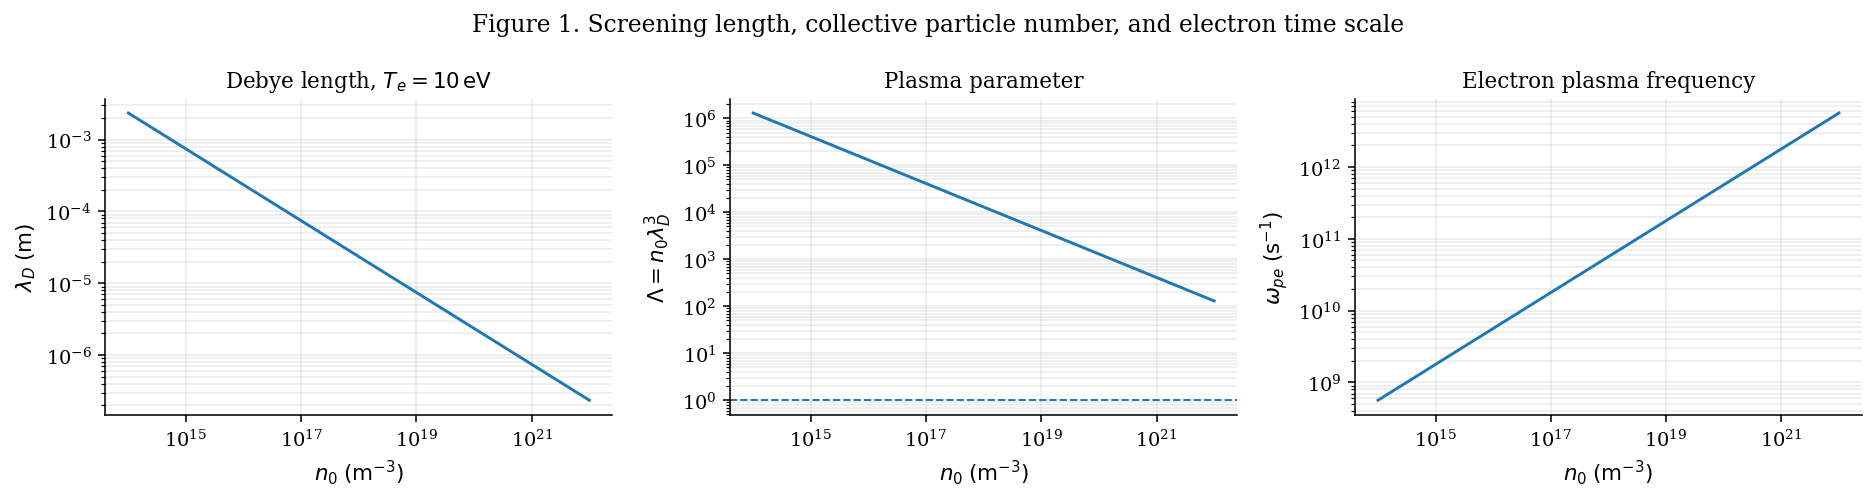

At n0 = 1.0e+18 m^-3 and Te = 10.0 eV:
lambda_D = 2.351e-05 m
Lambda   = 1.299e+04
omega_pe = 5.641e+10 s^-1


In [14]:
Te_eV = 10.0
Te = Te_eV * 11604.51812
n0 = np.logspace(14, 22, 700)

lambda_D = np.sqrt(eps0 * kB * Te / (n0 * e**2))
Lambda = n0 * lambda_D**3
omega_pe = np.sqrt(n0 * e**2 / (eps0 * me))

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))

axes[0].loglog(n0, lambda_D)
axes[0].set_xlabel(r"$n_0\;(\mathrm{m^{-3}})$")
axes[0].set_ylabel(r"$\lambda_D\;(\mathrm{m})$")
axes[0].set_title(r"Debye length, $T_e=10\,\mathrm{eV}$")
axes[0].grid(True, which="both", alpha=0.25)

axes[1].loglog(n0, Lambda)
axes[1].axhline(1, linestyle="--", linewidth=1)
axes[1].set_xlabel(r"$n_0\;(\mathrm{m^{-3}})$")
axes[1].set_ylabel(r"$\Lambda=n_0\lambda_D^3$")
axes[1].set_title("Plasma parameter")
axes[1].grid(True, which="both", alpha=0.25)

axes[2].loglog(n0, omega_pe)
axes[2].set_xlabel(r"$n_0\;(\mathrm{m^{-3}})$")
axes[2].set_ylabel(r"$\omega_{pe}\;(\mathrm{s^{-1}})$")
axes[2].set_title("Electron plasma frequency")
axes[2].grid(True, which="both", alpha=0.25)

fig.suptitle("Figure 1. Screening length, collective particle number, and electron time scale")
fig.tight_layout()
plt.show()

n_check = 1e18
lambda_check = np.sqrt(eps0 * kB * Te / (n_check * e**2))
Lambda_check = n_check * lambda_check**3
omega_check = np.sqrt(n_check * e**2 / (eps0 * me))

print(f"At n0 = {n_check:.1e} m^-3 and Te = {Te_eV:.1f} eV:")
print(f"lambda_D = {lambda_check:.3e} m")
print(f"Lambda   = {Lambda_check:.3e}")
print(f"omega_pe = {omega_check:.3e} s^-1")


**Figure 1. Screening length, collective particle number, and electron time scale**

Figure 1 summarizes the density dependence of the principal electrostatic scales at fixed electron temperature $T_e=10\,\mathrm{eV}$. Only relations needed for later kinetic modeling are emphasized.

The Debye length decreases with increasing density,

$$
\lambda_D=\left(\frac{\varepsilon_0 k_B T_e}{n_0 e^2}\right)^{1/2},
$$

so denser plasmas screen charge perturbations over shorter distances. This identifies the spatial scale below which charge separation may persist and above which quasineutrality is rapidly restored.

The plasma parameter,

$$
\Lambda=n_0\lambda_D^3,
$$

also decreases as $n_0^{-1/2}$ at fixed temperature, yet remains large throughout the plotted range. A large value of $\Lambda$ indicates that many particles participate in shielding, which supports the mean-field ordering required for the Vlasov model.

The electron plasma frequency increases with density,

$$
\omega_{pe}=\left(\frac{n_0 e^2}{\varepsilon_0 m_e}\right)^{1/2},
$$

and sets the characteristic timescale for rapid electron response. Higher density therefore corresponds to faster Langmuir-scale oscillations.

At the representative value $n_0=10^{18}\,\mathrm{m^{-3}}$,

$$
\lambda_D=2.35\times10^{-5}\,\mathrm{m},\qquad
\Lambda=1.30\times10^4,\qquad
\omega_{pe}=5.64\times10^{10}\,\mathrm{s^{-1}}.
$$

These values place the system in a strongly collective and weakly coupled regime appropriate for collisionless kinetic analysis.


---
<a id='1'></a>
## 1. Distribution Function in Phase Space

The ordering established above removes the need to resolve individual Coulomb encounters, but it does not by itself justify a fluid description. Langmuir waves and collisionless damping depend sensitively on the distribution of particles in velocity space. A kinetic description that retains velocity information is therefore required.

For a given species, the kinetic state is represented by a distribution function $f(\mathbf r,\mathbf v,t)$ on the six-dimensional phase space. It is defined through

$$
dN=f(\mathbf r,\mathbf v,t)\,d^3r\,d^3v,
$$

so that $dN$ denotes the number of particles in a spatial element $d^3r$ centered at $\mathbf r$ and a velocity-space element $d^3v$ centered at $\mathbf v$. Since $d^3v$ has units $\mathrm{m^3s^{-3}}$, the dimensions of $f$ are given by

$$
[f]=\mathrm{m^{-3}}(\mathrm{m\,s^{-1}})^{-3}
=\mathrm{s^3m^{-6}} .
$$

In kinetic theory, $\mathbf r$ and $\mathbf v$ are treated as independent variables. A single-particle trajectory satisfies $\mathbf r=\mathbf r(t)$ and $\mathbf v=\dot{\mathbf r}(t)$, whereas the distribution function is a field over all possible positions and velocities at a fixed time. This distinction is essential because acceleration redistribute density in velocity space in addition to modifying density in physical space.

The connection with macroscopic fluid variables is established through moments. The zeroth velocity moment yields the number density:

$$
n(\mathbf r,t)=\int_{\mathbb R^3} f(\mathbf r,\mathbf v,t)\,d^3v.
$$

The first velocity moment defines the mean flow velocity:

$$
\mathbf u(\mathbf r,t)
=
\frac{1}{n(\mathbf r,t)}
\int_{\mathbb R^3}\mathbf v f(\mathbf r,\mathbf v,t)\,d^3v.
$$

The second centered moment gives the pressure tensor:

$$
P_{ij}(\mathbf r,t)
=
m\int_{\mathbb R^3}
\big(v_i-u_i\big)\big(v_j-u_j\big)
f(\mathbf r,\mathbf v,t)\,d^3v .
$$

Fluid theory retains only a finite subset of these moments and closes the resulting hierarchy through auxiliary assumption. By contrast, kinetic theory keeps the distribution itself, and therefore retains the information required to describe velocity-space resonances and non-Maxwellian structure.

For linear Langmuir theory, the relevant unperturbed state is the simplest equilibrium consistent with fixed density and temperature.

For a spatially homogeneous electron equilibrium with zero bulk drift, the appropriate reference distribution is the Maxwellian

$$
f_0(\mathbf v)
=
n_0
\left(\frac{m_e}{2\pi k_B T_e}\right)^{3/2}
\exp\!\left(-\frac{m_e|\mathbf v|^2}{2k_B T_e}\right).
$$

Normalization follows from the Gaussian integral

$$
\int_{-\infty}^{\infty}
\exp\!\left(-\frac{m_ev_x^2}{2k_BT_e}\right)\,dv_x
=
\left(\frac{2\pi k_BT_e}{m_e}\right)^{1/2}.
$$

Since the three Cartesian velocity components factorize,

$$
\int_{\mathbb R^3} f_0(\mathbf v)\,d^3v
=
n_0
\left(\frac{m_e}{2\pi k_B T_e}\right)^{3/2}
\left(\frac{2\pi k_B T_e}{m_e}\right)^{3/2}
=
n_0.
$$

The Maxwellian may also be derived variationally. Maximization of the kinetic entropy functional

$$
S[f]=-k_B\int f\ln f\,d^3v
$$

subject to fixed particle density,

$$
\int f\,d^3v=n_0
$$

and fixed kinetic-energy density,

$$
\int \frac12 m_ev^2 f\,d^3v=\frac32 n_0k_BT_e
$$

gives

$$
\delta\left[
-k_B\int f\ln f\,d^3v
-\alpha\int f\,d^3v
-\beta\int \frac12m_ev^2f\,d^3v
\right]=0.
$$

The coefficient of $\delta f$ must therefore vanish:

$$
-k_B(\ln f+1)-\alpha-\frac{\beta m_ev^2}{2}=0.
$$

Thus

$$
f=A\exp(-Bv^2),
$$

where the constants are determined by the two constraints. This gives the Maxwellian above with $B=m_e/(2k_BT_e)$. The equilibrium is spatially uniform, isotropic in velocity space, and stationary in time. It serves as the background state about which the small-amplitude electron-density perturbations of Langmuir theory are constructed.

The remaining question is how the smooth distribution function itself emerges from the underlying many-particle dynamics.

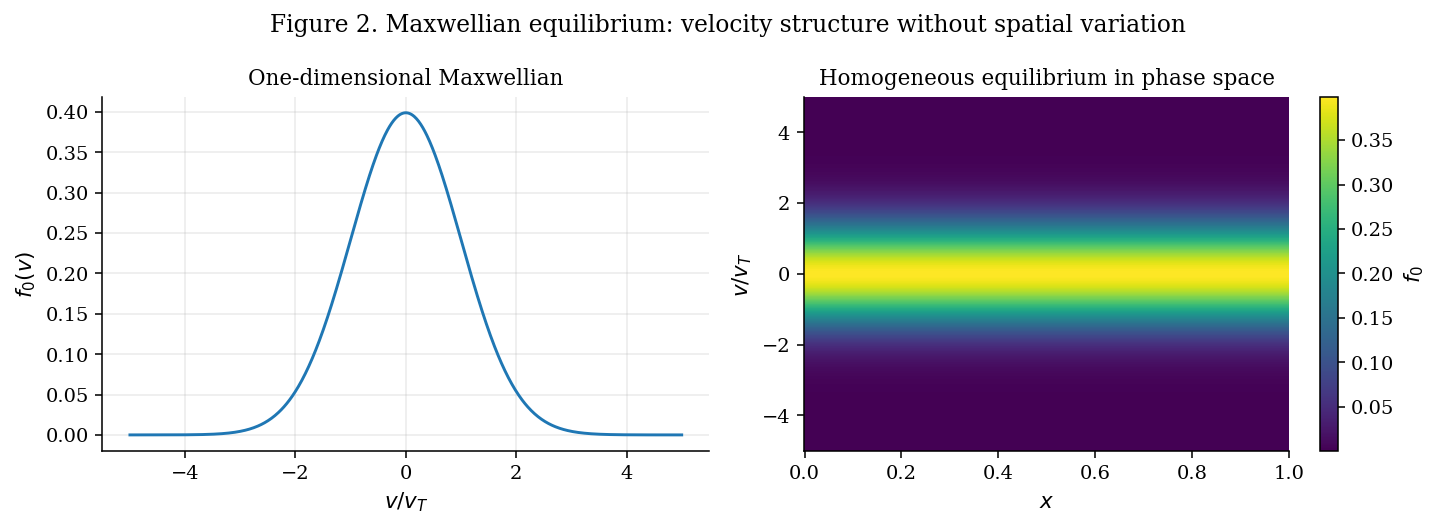

In [15]:
vT = 1.0
v = np.linspace(-5*vT, 5*vT, 800)
f1 = np.exp(-v**2/(2*vT**2)) / np.sqrt(2*np.pi*vT**2)

x = np.linspace(0, 1, 320)
X, V = np.meshgrid(x, v)
F = np.exp(-V**2/(2*vT**2)) / np.sqrt(2*np.pi*vT**2)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))

axes[0].plot(v/vT, f1)
axes[0].set_xlabel(r"$v/v_T$")
axes[0].set_ylabel(r"$f_0(v)$")
axes[0].set_title("One-dimensional Maxwellian")
axes[0].grid(alpha=0.25)

mesh = axes[1].pcolormesh(X, V/vT, F, shading="auto")
axes[1].set_xlabel(r"$x$")
axes[1].set_ylabel(r"$v/v_T$")
axes[1].set_title("Homogeneous equilibrium in phase space")
fig.colorbar(mesh, ax=axes[1], label=r"$f_0$")

fig.suptitle("Figure 2. Maxwellian equilibrium: velocity structure without spatial variation")
fig.tight_layout()
plt.show()


**Figure 2. Maxwellian equilibrium in velocity space and phase space**

Figure 2 illustrates the equilibrium state used in the linearized Vlasov analysis.

The left panel shows the one-dimensional Maxwellian velocity distribution,

$$
f_0(v)=\frac{1}{\sqrt{2\pi}\,v_{Te}}\exp\!\left(-\frac{v^2}{2v_{Te}^2}\right),
$$

centered at zero velocity. The symmetry about $v=0$ indicates zero bulk drift, while the width is determined by the electron thermal speed $v_{Te} = \sqrt{k_B T_e/m_e}$.

The right panel displays the same equilibrium in $(x,v)$ phase space. Because the state is spatially homogeneous, the distribution is independent of position and varies only with velocity. This provides the uniform background state upon which small electrostatic perturbations are introduced.

---
<a id='2'></a>
## 2. From Exact Particle Dynamics to the Vlasov Limit

The distribution function used in the Vlasov equation is the smooth limit of an exact microscopic phase-space density. For $N$ particles of a given species, with trajectories $\mathbf r_k(t)$ and velocities $\mathbf v_k(t)$, define the Klimontovich density by

$$
\mathcal N(\mathbf r,\mathbf v,t)
=
\sum_{k=1}^{N}
\delta^{(3)}\!\big(\mathbf r-\mathbf r_k(t)\big)
\delta^{(3)}\!\big(\mathbf v-\mathbf v_k(t)\big).
$$

This object is singular rather than smooth. Each particle contributes a delta spike at its instantaneous phase-space location. Integration over any phase-space region yields exactly the number particles contained in that region.

The equation for $\mathcal N$ follows directly from the chain rule. For one particle,

$$
\frac{\partial}{\partial t}
\delta^{(3)}(\mathbf r-\mathbf r_k(t))
=
-\dot{\mathbf r}_k(t)\cdot
\nabla_r\delta^{(3)}(\mathbf r-\mathbf r_k(t)),
$$

and

$$
\frac{\partial}{\partial t}
\delta^{(3)}(\mathbf v-\mathbf v_k(t))
=
-\dot{\mathbf v}_k(t)\cdot
\nabla_v\delta^{(3)}(\mathbf v-\mathbf v_k(t)).
$$

Applying the product rule to the two delta factors and summing over $k$ gives

$$
\frac{\partial \mathcal N}{\partial t}
=
-\sum_k
\dot{\mathbf r}_k\cdot\nabla_r
\left[
\delta^{(3)}(\mathbf r-\mathbf r_k)
\delta^{(3)}(\mathbf v-\mathbf v_k)
\right]
-\sum_k
\dot{\mathbf v}_k\cdot\nabla_v
\left[
\delta^{(3)}(\mathbf r-\mathbf r_k)
\delta^{(3)}(\mathbf v-\mathbf v_k)
\right].
$$

On the support of the $k$-th delta function, $\mathbf v = \mathbf v_k$. Newton’s equation of motion gives

$$
\dot{\mathbf v}_k=\frac{\mathbf F_{\mathrm{exact}}(\mathbf r_k,t)}{m}.
$$

The exact microscopic density therefore satisfies

$$
\boxed{
\frac{\partial \mathcal N}{\partial t}
+\mathbf v\cdot\nabla_r\mathcal N
+\frac{\mathbf F_{\mathrm{exact}}}{m}\cdot\nabla_v\mathcal N
=0
}
$$

in the sense of distributions. This relation is the Klimontovich equation: a Newtonian particle dynamics rewritten as a phase-space conservation law.

The smooth kinetic distribution is obtained by ensemble averaging or by coarse graining over volumes large relative to the inter-particle spacing but small relative to macroscopic scales:

$$
f(\mathbf r,\mathbf v,t)=\langle \mathcal N(\mathbf r,\mathbf v,t)\rangle.
$$

Decompose the microscopic electric field and density into mean and fluctuating parts,

$$
\mathbf E_{\mathrm{exact}}=\mathbf E+\delta\mathbf E,
\qquad
\mathcal N=f+\delta\mathcal N.
$$

Averaging the Klimontovich equation gives, for the electrostatic force $q\mathbf E_{\mathrm{exact}}$,

$$
\frac{\partial f}{\partial t}
+\mathbf v\cdot\nabla_r f
+\frac{q}{m}\mathbf E\cdot\nabla_v f
=
-\frac{q}{m}
\left\langle
\delta\mathbf E\cdot\nabla_v\delta\mathcal N
\right\rangle .
$$

The term on the right contains the correlation between microscopic field fluctuations and microscopic density fluctuations. Under weak-coupling closures, it generates collisional kinetic operators, including the Landau or Balescu--Lenard forms. It is neglected only in the collisionless mean-field approximation.

The ordering $\Lambda \gg 1$ provides the asymptotic basis for this approximation. Since many particles occupy a Debye sphere, fluctuations in the microscopic field are small relative to the averaged field at the collective scale. Collisional relaxation occurs on timescales longer than the electron plasma period, written schematically as

$$
\nu_{\mathrm{coll}}\ll\omega_{pe}.
$$

Neglecting the fluctuation-correlation term gives the Vlasov equation:

$$
\boxed{
\frac{\partial f}{\partial t}
+\mathbf v\cdot\nabla_r f
+\frac{q}{m}\mathbf E\cdot\nabla_v f=0
}.
$$

The electric field is generated self-consistently by the same distribution that it accelerates. For an electron distribution $f_e$ and fixed ion background $n_i=n_0$,

$$
\rho=e n_0-e\int f_e\,d^3v,
$$

so Poisson’s equation gives

$$
\nabla\cdot\mathbf E=\frac{1}{\varepsilon_0}
\left(
e n_0-e\int f_e\,d^3v
\right),
\qquad
\mathbf E=-\nabla\phi.
$$

Equivalently,

$$
-\nabla^2\phi
=
\frac{e}{\varepsilon_0}
\left(
n_0-\int f_e\,d^3v
\right).
$$

The Vlasov equation together with Poisson equation constitutes the Vlasov--Poisson system used to describe electrostatic Langmuir dynamics.

Its geometric content is clarified by viewing the equation as phase-space transport along particle trajectories.

---
<a id='3'></a>
## 3. Liouville Structure and Collisionless Transport

Collisionless motion transports phase-space density along the characteristics curves generated by the Lorentz force.

For a particle of charge $q$ and mass $m$,

$$
\dot{\mathbf r}=\mathbf v,
\qquad
\dot{\mathbf v}
=
\frac{q}{m}
\left(
\mathbf E+\mathbf v\times\mathbf B
\right)
$$

with the six-dimensional coordinate:

$$
\mathbf w=(\mathbf r,\mathbf v),
\qquad
\dot{\mathbf w}=(\dot{\mathbf r},\dot{\mathbf v}).
$$

the phase-space divergence of this flow is

$$
\nabla_w\cdot\dot{\mathbf w}
=
\nabla_r\cdot\mathbf v
+
\nabla_v\cdot
\frac{q}{m}
\left(
\mathbf E+\mathbf v\times\mathbf B
\right).
$$

The first term vanishes because velocity is independent of the spatial coordinates:

$$
\nabla_r\cdot\mathbf v
=
\sum_{i=1}^{3}\frac{\partial v_i}{\partial r_i}
=0.
$$

The electric part of the second term vanishes because $\mathbf E = \mathbf E(\mathbf r,t)$ has no velocity dependence:

$$
\nabla_v\cdot\mathbf E
=
\sum_{i=1}^{3}\frac{\partial E_i}{\partial v_i}
=0.
$$

For the magnetic term, use $(\mathbf v\times\mathbf B)_i = \varepsilon_{ijk} v_j B_k$. Then

$$
\nabla_v\cdot(\mathbf v\times\mathbf B)
=
\frac{\partial}{\partial v_i}
\left(\varepsilon_{ijk}v_jB_k\right)
=
\varepsilon_{ijk}\delta_{ij}B_k
=
\varepsilon_{jjk}B_k
=0.
$$

Thus

$$
\boxed{
\nabla_w\cdot\dot{\mathbf w}=0
}.
$$

This is Liouville’s theorem for nonrelativistic charged-particle flow: phase-space volume is preserved under Hamiltonian motion. A material element in phase space can stretch and shear, though not compressed.

Particle conservation in phase space is expressed by the continuity equation

$$
\frac{\partial f}{\partial t}
+
\nabla_w\cdot(f\dot{\mathbf w})=0 .
$$

Expanding the divergence,

$$
\frac{\partial f}{\partial t}
+
\dot{\mathbf w}\cdot\nabla_w f
+
f\,\nabla_w\cdot\dot{\mathbf w}
=0.
$$

Liouville’s theorem eliminates the last term, leaving

$$
\frac{\partial f}{\partial t}
+
\dot{\mathbf w}\cdot\nabla_w f=0.
$$

Substituting the equations of motion gives the full collisionless Vlasov equation,

$$
\boxed{
\frac{\partial f}{\partial t}
+
\mathbf v\cdot\nabla_r f
+
\frac{q}{m}
(\mathbf E+\mathbf v\times\mathbf B)\cdot\nabla_v f
=0
}.
$$

For the unmagnetized electrostatic electron model considered here,

$$
\mathbf B=0,\qquad
\mathbf E=-\nabla\phi,\qquad
q=-e,
$$

so the electron Vlasov equation becomes

$$
\boxed{
\frac{\partial f}{\partial t}
+
\mathbf v\cdot\nabla_r f
-
\frac{e}{m_e}\mathbf E\cdot\nabla_v f
=0
}.
$$

Along a characteristic curve $(\mathbf r(t),\mathbf v(t))$ satisfying

$$
\frac{d\mathbf r}{dt}=\mathbf v,
\qquad
\frac{d\mathbf v}{dt}=-\frac{e}{m_e}\mathbf E(\mathbf r,t),
$$

the total derivative of the distribution function is

$$
\frac{df}{dt}
=
\frac{\partial f}{\partial t}
+
\frac{d\mathbf r}{dt}\cdot\nabla_r f
+
\frac{d\mathbf v}{dt}\cdot\nabla_v f
=0.
$$

The fine-grained phase-space density is conserved along particle characteristics. Conservation along characteristics does not imply static phase-space geometry. Although phase mixing may generate increasingly fine filamentary structure, collisionless Vlasov evolution alone does not produce irreversible relaxation toward Maxwellian thermodynamic equilibrium.

This also gives a useful invariant. For any sufficiently smooth function $H$,

$$
\frac{d}{dt}\int H(f)\,d^3r\,d^3v
=
\int H'(f)\frac{\partial f}{\partial t}\,d^3r\,d^3v.
$$

Using the conservative form of the Vlasov equation,

$$
\frac{\partial f}{\partial t}=-\nabla_w\cdot(f\dot{\mathbf w}),
$$

and assuming periodic boundaries or decay at infinity, integration by parts gives

$$
\frac{d}{dt}\int H(f)\,d^3r\,d^3v=0.
$$

The Boltzmann functional

$$
S=-k_B\int f\ln f\,d^3r\,d^3v
$$

is therefore conserved by the fine-grained Vlasov equation. Numerical methods that introduce artificial diffusion change this invariant structure. For a simulation intended to demonstrate Langmuir waves, preserving mass and avoiding unphysical damping are not merely numerical preferences; they follow from the collisionless theory itself.

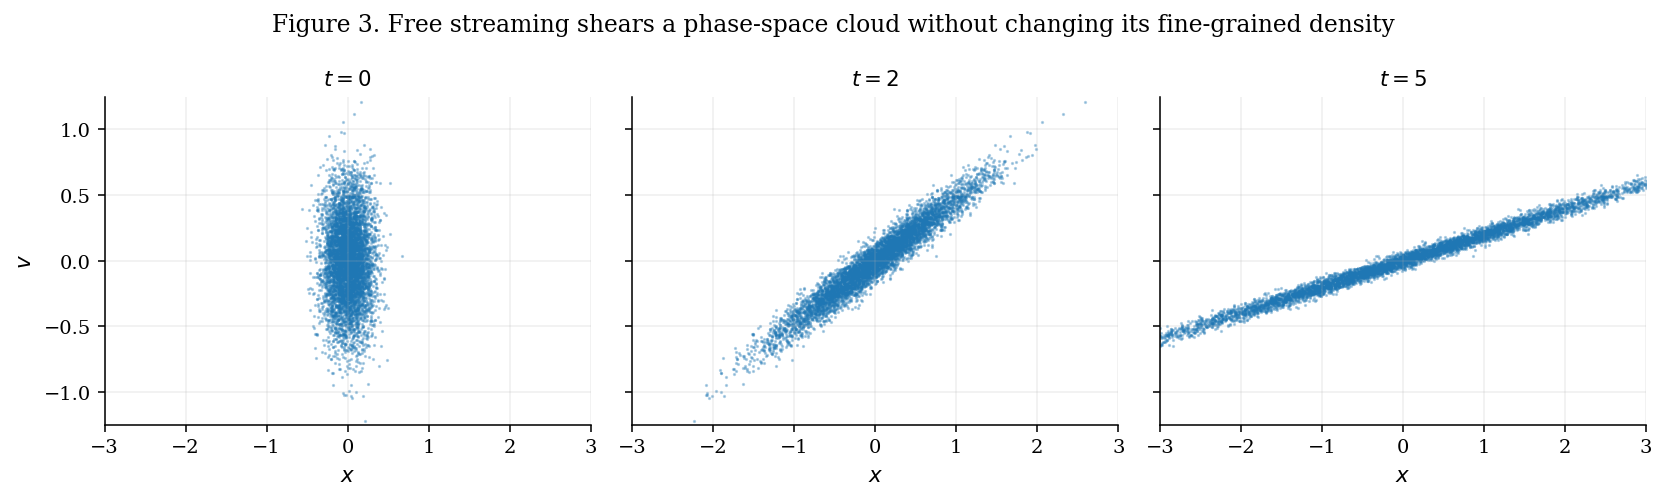

In [16]:
np.random.seed(4)

N = 6000
x0 = np.random.normal(0.0, 0.16, N)
v0 = np.random.normal(0.0, 0.30, N)

times = [0.0, 2.0, 5.0]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True, sharey=True)

for ax, t in zip(axes, times):
    x = x0 + v0 * t
    ax.scatter(x, v0, s=0.45, alpha=0.35, rasterized=True)
    ax.set_title(rf"$t={t:g}$")
    ax.set_xlabel(r"$x$")
    ax.grid(alpha=0.2)

axes[0].set_ylabel(r"$v$")
axes[0].set_xlim(-3.0, 3.0)
axes[0].set_ylim(-1.25, 1.25)

fig.suptitle("Figure 3. Free streaming shears a phase-space cloud without changing its fine-grained density")
fig.tight_layout()
plt.show()


**Figure 3. Free streaming and phase-space shear**

Figure 3 illustrates collisionless transport in the absence of forces,

$$
\frac{dx}{dt}=v,\qquad \frac{dv}{dt}=0.
$$

Particle velocities remain constant, while positions evolve according to

$$
x(t)=x_0+vt.
$$

The initially localized cloud is therefore sheared in phase space: particles with larger positive velocity move to increasing $x$, while those with negative velocity move oppositely.

The occupied region changes shape but not fine-grained phase-space area. This is the transport geometry underlying Liouville’s theorem and the collisionless Vlasov description.

The figure also indicates why numerical resolution is important. Smooth initial data develop increasingly fine filamentary structure under advection, so excessive numerical diffusion can suppress physically relevant phase-space evolution.

Sections 0 through 3 together establish the complete theoretical foundation for the numerical study that follows. Section 0 derived the screening length and plasma frequency from the collective-response requirement. Section 1 introduced the distribution function and fixed the Maxwellian equilibrium. Section 2 derived the Vlasov equation by averaging the Klimontovich description under the mean-field ordering $\Lambda\gg1$. Section 3 demonstrated that the resulting equation is a volume-preserving advection in phase space, generating a hierarchy of exact conservation laws that any faithful solver must respect. The Vlasov–Poisson system is now fully specified from first principles; the computational notebook that follows develops the discretisation scheme and validates it against the predictions of the linearised wave theory.

---
<a id='4'></a>
## 4. The Vlasov–Poisson System

### The Physical Narrative

The Vlasov equation derived in Section 3 describes how the distribution function $f(\mathbf{x}, \mathbf{v}, t)$ evolves once the electric field $\mathbf{E}$ is known. But the equation says nothing about where that field comes from. In an isolated plasma with no external source, the field is not imposed from outside — it is generated continuously by the very particles whose motion it governs. The problem is therefore self-referential: $\mathbf{E}$ shapes $f$, and $f$ determines $\mathbf{E}$. To make the problem tractable, the system must be **closed** — meaning we must supply the missing equation that relates the field back to the distribution. Poisson's equation provides exactly this closure.

The result is the **Vlasov–Poisson system**: a nonlinear, integro-differential feedback loop that is the foundational governing system for unmagnetized electrostatic plasma dynamics.

---

### 4.1 Assumptions of the Electrostatic Model

Before writing down the system, it is worth being precise about the physical regime we are targeting. The following assumptions are adopted, all inherited from the ordering established in 0 and the kinetic framework of 1–3.

**Assumption A1 — Electrostatic (unmagnetized) limit.** We neglect all magnetic perturbations generated by the plasma current. This is justified when the wave phase velocity $v_\phi = \omega / k$ satisfies $v_\phi \ll c$, which is well satisfied for Langmuir waves since $v_\phi \sim v_{Te} \ll c$. Under this limit, Faraday's law gives $\partial \mathbf{B}/\partial t \approx 0$, and the electric field is purely electrostatic:

$$
\mathbf{E} = -\nabla \phi. \tag{4.1}
$$

**Assumption A2 — Immobile ion background.** Ions are treated as a fixed, spatially uniform positive charge background of density $n_0$. This is justified by the mass ratio $m_i / m_e \gg 1$: on the timescale of electron plasma oscillations ($\omega_{pe}^{-1}$), ions barely move. Their contribution is therefore to maintain global charge neutrality, not to participate dynamically.

**Assumption A3 — Collisionless dynamics.** As established in Section 0, the plasma frequency greatly exceeds the collision frequency, $\omega_{pe} \gg \nu_{\mathrm{coll}}$. On the Langmuir oscillation timescale, inter-particle collisions are effectively frozen. This justified the Vlasov (zero right-hand side) equation in Sections 2–3, and it applies here as well.

**Assumption A4 — Non-relativistic electrons.** Electron velocities are assumed to satisfy $v \ll c$. This removes radiation reaction and relativistic corrections to the equations of motion.

**Assumption A5 — Single species.** We track only the electron distribution $f_e$. Because the ions are stationary, there is no separate ion kinetic equation to solve.

Together, these five assumptions reduce the full electromagnetic Boltzmann problem to a tractable electrostatic two-equation system.

---

### 4.2 The Vlasov–Poisson Equations

Under assumptions A1–A5, the governing equations are:

$$
\boxed{
\frac{\partial f_e}{\partial t}
+ \mathbf{v} \cdot \nabla_{\mathbf{x}} f_e
- \frac{e}{m_e} \mathbf{E} \cdot \nabla_{\mathbf{v}} f_e = 0
} \tag{4.2}
$$

$$
\boxed{
-\nabla^2 \phi = \frac{e}{\varepsilon_0}\!\left(n_0 - \int f_e \, d^3v\right), \qquad \mathbf{E} = -\nabla\phi
} \tag{4.3}
$$

**Variable anatomy:**
- $f_e(\mathbf{x}, \mathbf{v}, t)$ — electron distribution function $[\mathrm{s^3\,m^{-6}}]$.
- $\phi(\mathbf{x}, t)$ — electrostatic potential $[\mathrm{V}]$.
- $\mathbf{E}(\mathbf{x}, t) = -\nabla\phi$ — electric field $[\mathrm{V\,m^{-1}}]$; the force per unit charge.
- $n_0$ — uniform ion background density $[\mathrm{m^{-3}}]$; fixed throughout the simulation.
- $\int f_e \, d^3v = n_e(\mathbf{x}, t)$ — local electron number density $[\mathrm{m^{-3}}]$; this is the **zeroth moment** of the distribution. It collapses the full six-dimensional kinetic information into a three-dimensional spatial map.
- $\varepsilon_0$ — permittivity of free space $[\mathrm{F\,m^{-1}}]$.

**Provenance of Poisson's equation.** Equation (4.3) is simply Gauss's law, $\nabla \cdot \mathbf{E} = \rho / \varepsilon_0$, applied to the charge density $\rho = e(n_0 - n_e)$. The ion term $+e n_0$ represents the fixed positive background. The electron term $-e n_e = -e \int f_e \, d^3 v$ represents the local electron charge. On average $n_e = n_0$, so $\rho = 0$ and there is no mean field — only the perturbation field driven by fluctuations away from charge neutrality.

---

### 4.3 The Self-Consistent Loop: Logic and Structure

The two equations (4.2) and (4.3) constitute a closed dynamical system, but their coupling is intrinsically nonlinear: $\mathbf{E}$ depends on $f_e$ through the Poisson equation, and $f_e$ depends on $\mathbf{E}$ through the Vlasov equation. Neither can be solved independently.

The time evolution proceeds as the following cycle, repeated at each timestep $\Delta t$:

1. **$f_e \xrightarrow{\int d^3v} n_e(\mathbf{x},t)$** — Integrate the current distribution function over all velocities to obtain the local electron density at each spatial point.

2. **$n_e \xrightarrow{\text{Poisson}} \phi \xrightarrow{-\nabla} \mathbf{E}$** — Substitute $n_e$ into Poisson's equation and solve for the electrostatic potential $\phi$. Then differentiate to obtain the self-consistent field $\mathbf{E} = -\nabla\phi$.

3. **$\mathbf{E} \xrightarrow{\text{Vlasov}} f_e(t + \Delta t)$** — Use the electric field as the acceleration term in the Vlasov equation to advance the distribution function one timestep forward.

4. **Repeat.** The new $f_e$ generates a new $n_e$, which generates a new $\mathbf{E}$, which generates a new $f_e$, indefinitely. (The new positions create a new field, which creates new movement, indefinitely.)

This is the main "engine" of the simulation. We don't tell the particles where to go or give them a pre-set force from the outside. Instead, the particles create their own force just by moving around. When they bunch up in one spot, they create an electric field "hill." That field then immediately pushes those same particles toward the "valleys." As the particles move, the hills and valleys change, which then changes how the particles move next.

It’s a never-ending loop where the particles and the force are constantly reacting to each other in real-time.

---

### 4.4 The Maxwellian Equilibrium and the Poke

The Vlasov–Poisson system admits a trivial equilibrium: take $f_e = f_0(\mathbf{v})$ to be the spatially uniform Maxwellian from 1,

$$
f_0(\mathbf{v}) = n_0 \left(\frac{m_e}{2\pi k_B T_e}\right)^{3/2} \exp\!\left(-\frac{m_e |\mathbf{v}|^2}{2 k_B T_e}\right). \tag{4.4}
$$

In this state, $n_e = n_0$ everywhere, so the right-hand side of Poisson's equation vanishes, $\phi = 0$, and $\mathbf{E} = 0$. The Vlasov equation then reduces to $\partial f_0 / \partial t = 0$. The system is perfectly stationary: no forces, no evolution.

This is the "home base." The question that drives Sections 5 and 6 is what happens when the system is *perturbed*. We write

$$
f_e(\mathbf{x}, \mathbf{v}, t) = f_0(\mathbf{v}) + \delta f(\mathbf{x}, \mathbf{v}, t), \tag{4.5}
$$

where $|\delta f| \ll f_0$, and we call $\delta f$ the **perturbation** or "poke." Because $\delta f$ has spatial dependence, it induces a density fluctuation

$$
\delta n_e(\mathbf{x}, t) = \int \delta f \, d^3v \neq 0, \tag{4.6}
$$

which drives a non-zero $\mathbf{E}$ through Poisson's equation, which then feeds back on $f_e$ through the Vlasov equation. The loop is activated. Whether $\delta f$ grows, oscillates, or decays — this is the question of Langmuir wave theory and Landau damping, addressed in sections 5–6.

---

### 4.5 Conservation Properties of the Vlasov–Poisson System

The Vlasov–Poisson system is not merely a convenient model — it is a Hamiltonian system with conserved quantities that constrain the physics and serve as strict tests for numerical implementations.

**Particle number.** Integrating the Vlasov equation over phase space and using the divergence theorem,

$$
\frac{d}{dt} \int f_e \, d^3x \, d^3v = 0, \tag{4.7}
$$

so the total number of electrons is exactly conserved. In a simulation, deviations from particle conservation indicate truncation error or unphysical dissipation.

**Total energy.** The total energy of the system is the sum of kinetic and field energies:

$$
\mathcal{E} = \frac{m_e}{2} \int v^2 f_e \, d^3x \, d^3v + \frac{\varepsilon_0}{2} \int |\mathbf{E}|^2 \, d^3x. \tag{4.8}
$$

One can show, using the Vlasov and Poisson equations together, that $d\mathcal{E}/dt = 0$. Physically, this reflects the fact that Lorentz forces do no work on charges (in the electrostatic limit, the force is conservative) and energy merely exchanges between kinetic and field forms.

**Casimir invariants.** As shown in 3, for any smooth function $H$,

$$
\frac{d}{dt}\int H(f_e) \, d^3x \, d^3v = 0, \tag{4.9}
$$

by Liouville's theorem. The functional $-\int f_e \ln f_e \, d^3x \, d^3v$ (the fine-grained entropy) is therefore also conserved. A collisionless Vlasov plasma cannot irreversibly thermalize — the distribution function merely develops increasingly fine filamentary structure in velocity space, a process called **phase mixing**.

These conservation laws are not incidental — they represent the underlying symplectic structure of the Hamiltonian dynamics and are what make the Vlasov–Poisson system qualitatively different from a dissipative fluid model.


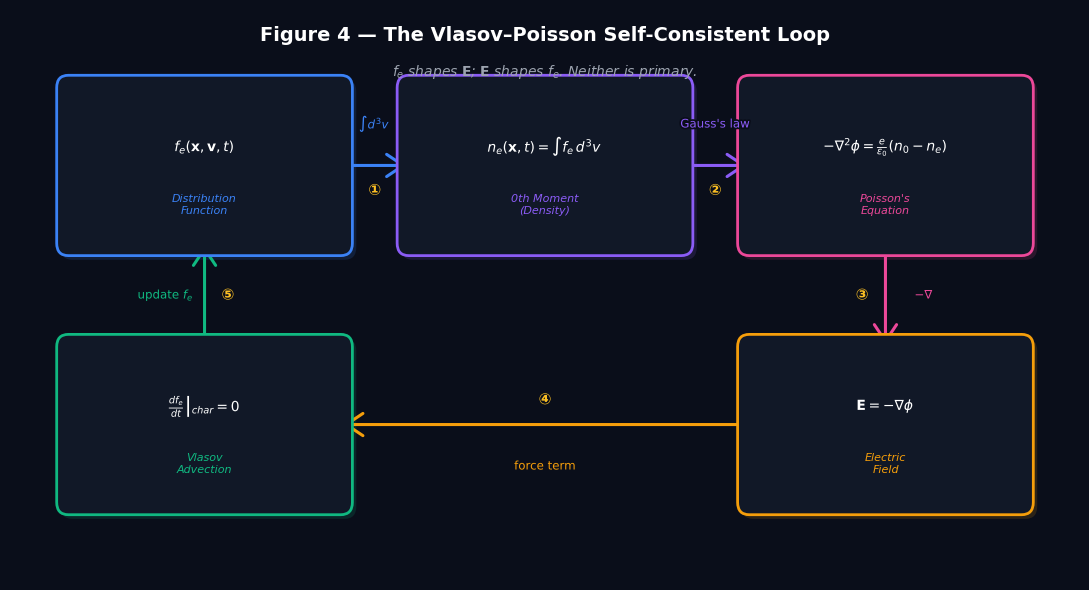

In [ ]:
# ── Setup Figure ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
ax.set_xlim(0, 11)
ax.set_ylim(0, 5.5)
ax.axis('off')
ax.set_facecolor('#0a0e1a')
fig.patch.set_facecolor('#0a0e1a')

# ── Node definitions ─────────────────────────────────────────────────────────
# (cx, cy, top_label, bot_label, accent_color)
nodes = [
    (2.0,  4.0,
     r'$f_e(\mathbf{x},\mathbf{v},t)$',
     'Distribution\nFunction',
     '#3b82f6'),   # blue
    (5.5,  4.0,
     r'$n_e(\mathbf{x},t) = \int f_e\,d^3v$',
     '0th Moment\n(Density)',
     '#8b5cf6'),   # violet
    (9.0,  4.0,
     r'$-\nabla^2\phi = \frac{e}{\varepsilon_0}(n_0 - n_e)$',
     "Poisson's\nEquation",
     '#ec4899'),   # pink
    (9.0,  1.5,
     r'$\mathbf{E} = -\nabla\phi$',
     'Electric\nField',
     '#f59e0b'),   # amber
    (2.0,  1.5,
     r'$\left. \frac{df_e}{dt} \right|_{char} = 0$', # FIXED: Matplotlib compatible LaTeX
     'Vlasov\nAdvection',
     '#10b981'),   # emerald
]

box_w, box_h = 2.8, 1.5

def draw_node(ax, cx, cy, top_label, bot_label, color):
    # Glow shadow
    rect_shadow = mpatches.FancyBboxPatch(
        (cx - box_w/2 + 0.04, cy - box_h/2 - 0.04), box_w, box_h,
        boxstyle="round,pad=0.12",
        linewidth=0, edgecolor='none',
        facecolor=color, zorder=2, alpha=0.15)
    ax.add_patch(rect_shadow)
    
    # Main box
    rect = mpatches.FancyBboxPatch(
        (cx - box_w/2, cy - box_h/2), box_w, box_h,
        boxstyle="round,pad=0.12",
        linewidth=2, edgecolor=color,
        facecolor='#111827',
        zorder=3)
    ax.add_patch(rect)
    
    # Top equation label
    ax.text(cx, cy + 0.18, top_label,
            ha='center', va='center',
            fontsize=10, color='white', zorder=4,
            path_effects=[pe.withStroke(linewidth=2, foreground='#111827')])
    
    # Bottom descriptor label
    ax.text(cx, cy - 0.38, bot_label,
            ha='center', va='center',
            fontsize=8, color=color, zorder=4, linespacing=1.3,
            fontstyle='italic')

for cx, cy, tl, bl, col in nodes:
    draw_node(ax, cx, cy, tl, bl, col)

# ── Arrow definitions ────────────────────────────────────────────────────────
# (x0, y0, x1, y1, step_label, mid_label, color)
arrows = [
    # f -> density (top row)
    (2.0 + box_w/2, 4.0,   5.5 - box_w/2, 4.0,
     '①', r'$\int d^3v$',  '#3b82f6'),
    # density -> Poisson (top row)
    (5.5 + box_w/2, 4.0,   9.0 - box_w/2, 4.0,
     '②', "Gauss's law",  '#8b5cf6'),
    # Poisson -> E (right column)
    (9.0, 4.0 - box_h/2,   9.0, 1.5 + box_h/2,
     '③', r'$-\nabla$',    '#ec4899'),
    # E -> Vlasov (bottom row)
    (9.0 - box_w/2, 1.5,   2.0 + box_w/2, 1.5,
     '④', 'force term',    '#f59e0b'),
    # Vlasov -> f (left column)
    (2.0, 1.5 + box_h/2,   2.0, 4.0 - box_h/2,
     '⑤', r'update $f_e$', '#10b981'),
]

for x0, y0, x1, y1, step, lbl, col in arrows:
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->,head_width=0.4,head_length=0.6', 
                                color=col, lw=2.2,
                                mutation_scale=20,
                                connectionstyle='arc3,rad=0.0'),
                zorder=2)
    
    # Midpoint label (perpendicular offset)
    mx, my = (x0+x1)/2, (y0+y1)/2
    dx, dy = (x1-x0), (y1-y0)
    length = np.sqrt(dx**2 + dy**2)
    px, py = -dy/length * 0.4, dx/length * 0.4
    
    # Connection description
    ax.text(mx + px, my + py, lbl,
            ha='center', va='center', fontsize=8.5, color=col, zorder=5,
            path_effects=[pe.withStroke(linewidth=2.5, foreground='#0a0e1a')])
    
    # Step number circle
    ax.text(mx - px*0.6, my - py*0.6, step,
            ha='center', va='center', fontsize=11,
            color='#fbbf24', fontweight='bold', zorder=6,
            path_effects=[pe.withStroke(linewidth=2.5, foreground='#0a0e1a')])

# ── Titles ───────────────────────────────────────────────────────────────────
ax.text(5.5, 5.25, 'Figure 4 — The Vlasov–Poisson Self-Consistent Loop',
        ha='center', va='center', fontsize=14, fontweight='bold',
        color='white')
ax.text(5.5, 4.9, r'$f_e$ shapes $\mathbf{E}$; $\mathbf{E}$ shapes $f_e$. Neither is primary.',
        ha='center', va='center', fontsize=10, color='#9ca3af', style='italic')

plt.tight_layout()
plt.show()

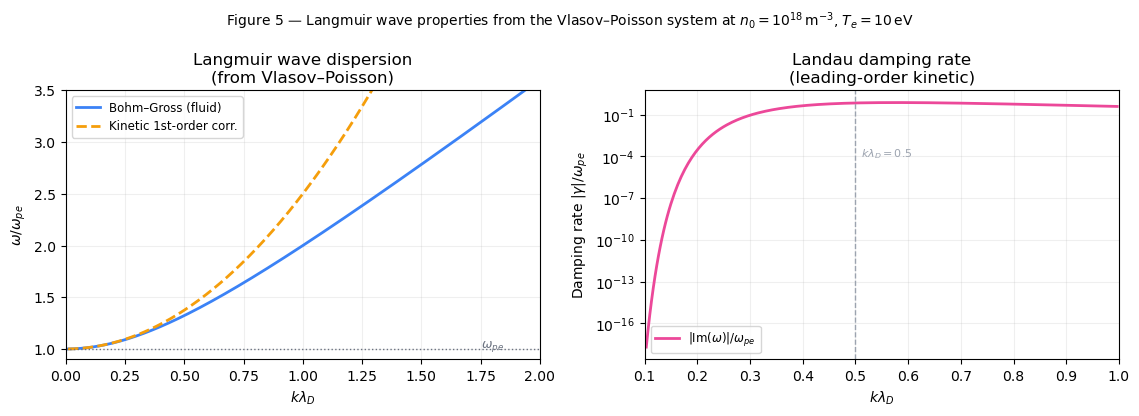

omega_pe = 5.641e+10 s^-1
lambda_D = 2.351e-05 m
v_Te     = 1.326e+06 m/s
At k*lD = 0.3:  omega/omega_pe = 1.1269  (Bohm-Gross)


In [3]:
# ── Figure 5: Langmuir dispersion relation from the Vlasov–Poisson system ─────

# Physical constants (SI)
eps0 = 8.8541878128e-12
kB   = 1.380649e-23
e    = 1.602176634e-19
me   = 9.1093837015e-31

# Representative parameters
Te_eV = 10.0
Te    = Te_eV * e          # [J]
n0    = 1e18               # [m^{-3}]

omega_pe = np.sqrt(n0 * e**2 / (eps0 * me))
lambda_D = np.sqrt(eps0 * Te / (n0 * e**2))
vTe      = np.sqrt(Te / me)

k = np.linspace(0.01, 2.0, 600) / lambda_D   # wave-number [m^{-1}]
klD = k * lambda_D                            # dimensionless

# Bohm–Gross dispersion relation (fluid / warm plasma limit)
# omega^2 = omega_pe^2 (1 + 3 k^2 lambda_D^2)
omega_BG = omega_pe * np.sqrt(1.0 + 3.0 * klD**2)

# Kinetic correction: first-order thermal correction to Re(omega)
# omega ~ omega_pe (1 + 3/2 k^2 lambda_D^2)  for k lambda_D << 1
omega_kinetic = omega_pe * (1.0 + 1.5 * klD**2)

# Landau damping rate (leading order, valid for k lambda_D << 1)
# Im(omega) ~ -sqrt(pi/8) * omega_pe/(k lambda_D)^3 * exp(-1/(2k^2 lambda_D^2))
# only meaningful for small k lambda_D; clip to avoid overflow
with np.errstate(over='ignore', invalid='ignore'):
    exponent = -1.0 / (2.0 * klD**2 + 1e-12)
    gamma_L  = np.sqrt(np.pi / 8.0) * omega_pe / klD**3 * np.exp(exponent)
    gamma_L  = np.where(klD < 0.05, 0.0, np.abs(gamma_L))   # suppress tiny-k divergence

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

# ── Left panel: dispersion relation ──────────────────────────────────────────
ax = axes[0]
ax.plot(klD, omega_BG   / omega_pe, lw=2,   label='Bohm–Gross (fluid)',  color='#3b82f6')
ax.plot(klD, omega_kinetic / omega_pe, lw=2, ls='--',
        label=r'Kinetic 1st-order corr.', color='#f59e0b')
ax.axhline(1.0, color='#6b7280', lw=1, ls=':')
ax.text(1.75, 1.02, r'$\omega_{pe}$', color='#6b7280', fontsize=9)
ax.set_xlabel(r'$k\lambda_D$')
ax.set_ylabel(r'$\omega / \omega_{pe}$')
ax.set_title('Langmuir wave dispersion\n(from Vlasov–Poisson)')
ax.legend(fontsize=8.5)
ax.set_xlim(0, 2); ax.set_ylim(0.9, 3.5)
ax.grid(alpha=0.2)

# ── Right panel: Landau damping rate ────────────────────────────────────────
ax2 = axes[1]
mask = (klD >= 0.1) & (klD <= 1.0)
ax2.semilogy(klD[mask], gamma_L[mask] / omega_pe, lw=2, color='#ec4899',
             label=r'$|\mathrm{Im}(\omega)|/\omega_{pe}$')
ax2.axvline(0.5, color='#9ca3af', lw=1, ls='--')
ax2.text(0.51, 1e-4, r'$k\lambda_D = 0.5$', color='#9ca3af', fontsize=8)
ax2.set_xlabel(r'$k\lambda_D$')
ax2.set_ylabel(r'Damping rate $|\gamma|/\omega_{pe}$')
ax2.set_title('Landau damping rate\n(leading-order kinetic)')
ax2.legend(fontsize=8.5)
ax2.set_xlim(0.1, 1.0)
ax2.grid(alpha=0.2)

fig.suptitle(
    r'Figure 5 — Langmuir wave properties from the Vlasov–Poisson system at '
    r'$n_0 = 10^{18}\,\mathrm{m^{-3}}$, $T_e = 10\,\mathrm{eV}$',
    fontsize=10)
fig.tight_layout()
plt.show()

print(f"omega_pe = {omega_pe:.3e} s^-1")
print(f"lambda_D = {lambda_D:.3e} m")
print(f"v_Te     = {vTe:.3e} m/s")
print(f"At k*lD = 0.3:  omega/omega_pe = {np.sqrt(1+3*0.3**2):.4f}  (Bohm-Gross)")

**Figure 5. demonstrates dispersion and damping from the Vlasov–Poisson system.**

The two panels confirm the physical predictions that emerge from the self-consistent loop.

*Left panel* — The Langmuir wave dispersion relation. For long wavelengths ($k\lambda_D \ll 1$), the wave frequency approaches $\omega_{pe}$ from above: the plasma oscillates at its natural frequency and thermal corrections are small. As $k\lambda_D$ increases, kinetic pressure stiffens the response and $\omega$ rises. The Bohm–Gross relation,

$$
\omega^2 = \omega_{pe}^2\!\left(1 + 3k^2\lambda_D^2\right), \tag{4.10}
$$

captures this in the fluid limit. The kinetic first-order correction shifts the curve slightly but preserves the qualitative structure. Both branches approach $\omega_{pe}$ as $k \to 0$, confirming that Langmuir waves are fundamentally tied to the plasma frequency set in Section 0.

*Right panel* — The Landau damping rate $|\mathrm{Im}(\omega)|$, the quintessential kinetic effect that is invisible to fluid models. For $k\lambda_D \lesssim 0.3$ the damping is exponentially small (long-wave oscillations decay negligibly), but it grows steeply as $k\lambda_D \to 1$, where the wave phase velocity approaches the thermal velocity and resonant wave–particle energy exchange becomes efficient. This is the signal that the velocity-space structure of $f_e$ — retained by the Vlasov equation but discarded by fluid truncation — is physically essential. The derivation of the damping rate will be tackled later on in part 6.


---
<a id='5'></a>
## 5. Linearisation and Wave Modes

The Vlasov–Poisson system assembled in Section 4 is self-consistent but nonlinear: the coupling term $\mathbf{E}\cdot\partial f/\partial\mathbf{v}$ (1D, explained in the next section) multiplies two unknowns, making the system analytically intractable. Validating any simulation requires a prior analytical prediction — at what frequency should the plasma oscillate, and at what rate should oscillations decay? Producing that prediction demands a simplification strategy: **linearisation**.

---
#### Sidenote:
> **Notation bridge.** Sections 5–6 specialize the 3D framework to a longitudinal plane wave
> propagating along $\hat{x}$. Under this symmetry $\partial/\partial y = \partial/\partial z = 0$
> and $E_y = E_z = 0$, so the vector Vlasov equation reduces *exactly* to a 1D scalar equation
> in $(x,v)$ where $v \equiv v_x$ and $E \equiv E_x$. Integrating the 3D Maxwellian
> $f_0(\mathbf{v})$ over $v_y$ and $v_z$ yields the 1D marginal
> $f_0(v) = (n_0/\sqrt{2\pi}\,v_{Te})\exp(-v^2/2v_{Te}^2)$, which serves as the equilibrium
> throughout the linearisation. The electron subscript $e$ is dropped for brevity (ions remain
> a fixed background), and the perturbation notation is relabelled $f_1 \equiv \delta f$,
> $\phi_1 \equiv \delta\phi$, $E_1 \equiv \delta E$, consistent with Section 4.

>> See [[Appendix]](#8) for full derivations. 



---

### 5.1 The Perturbation Ansatz

#### 5.1.1 Background: What Is an Ansatz and Why Do We Need One?

An **Ansatz** (German: "starting point") is an educated guess for the solution's form. Since physics suggests that small waves exist atop an otherwise uniform background, the Perturbation Ansatz decomposes every quantity into a **background part** (the plasma at rest) and a **perturbation** (the small wave riding on top).

#### 5.1.2 The Equilibrium State

An equilibrium $f_0$ must satisfy two independent requirements:

1. **Spatial uniformity.** $f_0$ must be independent of $x$; any dependence would imply pre-existing charge-density gradients that destroy the steady state.
2. **Quasineutrality.** The electron density must match the ion background: $n_e = \int f_0\,dv = n_0$. As shown in Section 0, this forces the background potential to vanish:

$$\nabla^2\phi_0 = -\frac{\rho_0}{\varepsilon_0} = -\frac{e(n_0 - n_0)}{\varepsilon_0} = 0 \implies \phi_0 = 0. \tag{5.1}$$

Hence $\mathbf{E}_0 = -\nabla\phi_0 = 0$: the equilibrium plasma is electrically inert. The unique choice consistent with thermal equilibrium is the **Maxwellian distribution**:

$$f_0(v) = \frac{n_0}{\sqrt{2\pi}\,v_{Te}}\exp\!\left(-\frac{v^2}{2v_{Te}^2}\right), \qquad v_{Te} = \sqrt{\frac{k_B T_e}{m_e}}, \tag{5.2}$$

where $v_{Te}$ is the **electron thermal velocity**. The slope $\partial f_0/\partial v$ is negative for $v > 0$ and positive for $v < 0$ — a fact that drives the entire energy-exchange mechanism of Landau damping.

#### 5.1.3 The Decomposition

We write the full distribution and potential as:

$$\boxed{f(x, v, t) = f_0(v) + f_1(x, v, t),} \qquad |f_1| \ll f_0. \tag{5.3}$$

$$\phi(x, t) = 0 + \phi_1(x, t), \qquad E_1 = -\partial_x\phi_1. \tag{5.4}$$

**Variable anatomy:**

| Symbol | Name | Physical Role |
|--------|------|---------------|
| $f_0(v)$ | Equilibrium distribution | Smooth Maxwellian; encodes plasma temperature and density at rest |
| $f_1(x,v,t)$ | Perturbation | The "shiver" — the small, space- and time-dependent deviation |
| $\phi_1(x,t)$ | Perturbed potential | Electric potential created by the charge-density imbalance |
| $E_1 = -\partial_x\phi_1$ | Perturbed electric field | Restoring force acting on perturbed electrons |

The condition $|f_1| \ll f_0$ is the **mathematical licence** for all that follows: products of two perturbation quantities (e.g. $f_1 \cdot E_1$) are second-order and discarded — the essence of linear theory.

---

### 5.2 Derivation of the Linearised Kinetic Equation

#### 5.2.1 Background: Why the Full Equation is Nonlinear

The 1D electrostatic Vlasov equation (Section 4) is:

$$\frac{\partial f}{\partial t} + v\frac{\partial f}{\partial x} - \frac{e}{m_e}E\frac{\partial f}{\partial v} = 0. \tag{5.5}$$

The nonlinearity lives in $E \cdot \partial f/\partial v$: both $E$ and $f$ are unknowns coupled through the self-consistent loop of Section 4, so their product is quadratic and superposition fails. Linearisation makes the coupling effectively linear.

#### 5.2.2 Substitution

Substituting (5.3) and (5.4) into (5.5) with $f \to f_0 + f_1$ and $E \to E_1$:

$$\frac{\partial (f_0 + f_1)}{\partial t} + v\frac{\partial (f_0 + f_1)}{\partial x} - \frac{e}{m_e}E_1\frac{\partial (f_0 + f_1)}{\partial v} = 0. \tag{5.6}$$

Expanding term by term:

- $\partial f_0/\partial t = 0$: equilibrium is time-independent.
- $v\,\partial f_0/\partial x = 0$: equilibrium is spatially uniform.
- $-(e/m_e)E_1\,\partial f_0/\partial v$: **first order** (one perturbation quantity, $E_1$) — **kept**.
- $-(e/m_e)E_1\,\partial f_1/\partial v$: **second order** ($E_1$ and $f_1$) — **dropped**.

What remains is the **linearised Vlasov equation**:

$$\boxed{\frac{\partial f_1}{\partial t} + v\frac{\partial f_1}{\partial x} = \frac{e}{m_e}E_1\frac{\partial f_0}{\partial v}.} \tag{5.7}$$

The left-hand side is a pure advection operator on $f_1$; the right-hand side drives the perturbation through the equilibrium slope.

#### 5.2.3 Structural Observation: The Role of $\partial f_0/\partial v$

The coupling term $E_1\,\partial f_0/\partial v$ is the central structure of linear kinetic theory: **the wave couples most strongly to particles where the distribution has the steepest slope.**

- $\partial f_0/\partial v < 0$ at the resonant velocity (Maxwellian): wave loses energy — **damped**.
- $\partial f_0/\partial v > 0$ at the resonant velocity (beam): wave gains energy — **grows** (kinetic instability).

This is a preview of Landau damping; the sign and magnitude of the coupling term determine the wave's fate, as computed in Section 6.

#### 5.2.4 The Linearised Poisson Equation

The perturbed charge density comes solely from $f_1$:

$$\frac{\partial^2 \phi_1}{\partial x^2} = \frac{e}{\varepsilon_0}\int_{-\infty}^{\infty} f_1\,dv. \tag{5.8}$$

Together, (5.7) and (5.8) form the **linearised Vlasov–Poisson system** — two linear equations in $f_1$ and $\phi_1$ whose solutions are the plasma's wave modes.

---

### 5.3 Normal Mode Analysis: The Plane-Wave Ansatz

#### 5.3.1 Background: Why Fourier Modes?

Equations (5.7) and (5.8) are linear PDEs with constant coefficients (neither $f_0$, $e$, nor $m_e$ depends on $x$ or $t$). For such equations, Fourier's theorem guarantees that any disturbance decomposes into a superposition of plane waves — so knowing how each plane wave behaves independently determines how every disturbance behaves. Complex exponentials are the **eigenfunctions** of the derivative operators: since $\partial/\partial x\,e^{i(kx-\omega t)} = ik\,e^{i(kx-\omega t)}$ and $\partial/\partial t\,e^{i(kx-\omega t)} = -i\omega\,e^{i(kx-\omega t)}$, every derivative is replaced by an algebraic factor, converting the PDE into an algebraic equation for $(k,\omega)$.

#### 5.3.2 The Ansatz

We assume:

$$f_1(x, v, t) = \hat{f}_1(v)\,e^{i(kx - \omega t)}, \qquad E_1(x, t) = \hat{E}_1\,e^{i(kx - \omega t)}, \tag{5.9}$$

| Symbol | Name | Physical Meaning |
|--------|------|-----------------|
| $k$ | Wavenumber (rad m$^{-1}$) | Spatial frequency: $k = 2\pi/\lambda$; set by the simulation box size |
| $\omega$ | Complex frequency (rad s$^{-1}$) | $\omega = \omega_r + i\gamma$: real part gives oscillation rate, imaginary part gives growth ($\gamma > 0$) or decay ($\gamma < 0$) |
| $\hat{f}_1(v)$ | Velocity amplitude | Velocity-space shape of the perturbation |
| $\hat{E}_1$ | Electric-field amplitude | A scalar; the field must oscillate in step with the particles for the wave to be self-consistent |

Physical quantities are the **real parts** of these complex expressions; the complex form is adopted purely for algebraic convenience.

---

### 5.4 Solving for the Perturbed Distribution $\hat{f}_1$

#### 5.4.1 Substituting the Ansatz into the Linearised Vlasov Equation

Substituting (5.9) into (5.7), the common exponential $e^{i(kx-\omega t)}$ cancels, leaving:

$$i(kv - \omega)\,\hat{f}_1 = \frac{e}{m_e}\hat{E}_1\frac{\partial f_0}{\partial v}. \tag{5.11}$$

Solving for $\hat{f}_1$:

$$\boxed{\hat{f}_1(v) = -\frac{e\hat{E}_1}{im_e}\cdot\frac{\partial f_0/\partial v}{(\omega - kv)}.} \tag{5.12}$$

#### 5.4.2 Variable Anatomy and Physical Interpretation

| Factor | Physical Role |
|--------|---------------|
| $e\hat{E}_1/m_e$ | Acceleration imparted to an electron by the wave field — the "kick strength" |
| $\partial f_0/\partial v$ | Local slope of the Maxwellian — determines how many electrons are available at each speed |
| $(\omega - kv)^{-1}$ | **Resonant denominator** — measures how "in tune" a particle is with the wave |

The denominator vanishes at $v = \omega/k \equiv v_\phi$, the **phase velocity**. A particle at $v_\phi$ sees a static electric force and accumulates an unbounded kick — this is the resonant energy exchange Landau identified, and it renders the integral in the next step singular.

---

### 5.5 The Dispersion Relation and the Dielectric Function

#### 5.5.1 Closing the Loop: Poisson's Equation

Equation (5.12) expresses $\hat{f}_1$ in terms of $\hat{E}_1$, but does not yet constrain which $(k, \omega)$ pairs are physically permitted. **Self-consistency** requires that $f_1$ generate the same charge density that produces, via Poisson's equation, the assumed field $E_1$. Substituting the plane-wave ansatz into (5.8) and using $\hat{E}_1 = -ik\hat{\phi}_1$:

$$ik\hat{E}_1 = \frac{e}{\varepsilon_0}\int_{-\infty}^{\infty}\hat{f}_1(v)\,dv. \tag{5.13}$$

#### 5.5.2 Substituting $\hat{f}_1$

Inserting (5.12) into (5.13), the amplitude $\hat{E}_1$ cancels from both sides — its cancellation signals that we seek **normal modes**, self-sustaining oscillations requiring no external driver:

$$1 = \frac{e^2}{km_e\varepsilon_0}\int_{-\infty}^{\infty}\frac{\partial f_0/\partial v}{kv - \omega}\,dv. \tag{5.15}$$

Defining the normalised distribution $\hat{f}_0 = f_0/n_0$ and recognising $\omega_{pe}^2 = n_0 e^2/(m_e\varepsilon_0)$:

$$\boxed{\varepsilon(k,\omega) \equiv 1 - \frac{\omega_{pe}^2}{k^2}\int_{-\infty}^{\infty}\frac{\partial\hat{f}_0/\partial v}{v - \omega/k}\,dv = 0.} \tag{5.17}$$

This is the **electrostatic dispersion relation**; $\varepsilon(k,\omega)$ is the **Dielectric Function** of the plasma.

---

### 5.5.3 The Dielectric Function: Physical Meaning and Why It Must Vanish

The dielectric function measures the plasma's **ability to polarise in response to an oscillating field**, and hence its capacity to support a self-sustaining wave. The condition $\varepsilon = 0$ is the self-consistency requirement: the field sustains the particles that sustain the field — a closed feedback loop with no external energy input.

Its structure is most transparent written as:

$$\varepsilon(k,\omega) = \underbrace{1}_{\text{vacuum}} - \underbrace{\frac{\omega_{pe}^2}{k^2}\int\frac{\partial\hat{f}_0/\partial v}{v - \omega/k}\,dv}_{\text{plasma polarisation response}}. \tag{5.18}$$

- The **"1"** is the vacuum contribution — a field in free space with no medium.
- The **integral** is the plasma's induced response; electrons near $v \approx \omega/k$ contribute most strongly (smallest denominator).

| $\varepsilon$ value | Physical Interpretation |
|---------------------|------------------------|
| $\varepsilon > 0$ | Over-shielding: electrons cancel any perturbation before it can propagate. No wave. |
| $\varepsilon < 0$ | Under-shielding: the response overshoots, amplifying the field — possible instability. |
| $\varepsilon = 0$ | **Resonance**: plasma polarisation exactly sustains the wave. A self-consistent oscillation exists. |

> **Connection to the simulation.** $\varepsilon(k,\omega) = 0$ gives a direct validation recipe: choose $k$ from the grid, solve analytically for $(\omega_r, \gamma)$, run the simulation, and compare. Any mismatch signals an inaccurate or unphysical numerical scheme.

Section 5 has produced the central object of the project — the dispersion relation $\varepsilon(k,\omega) = 0$ — but immediately exposed a singularity in (5.17) at $v = \omega/k$, where the denominator vanishes at the resonant velocity. Section 6 resolves this singularity, extracting from it both the oscillation frequency and the damping rate.

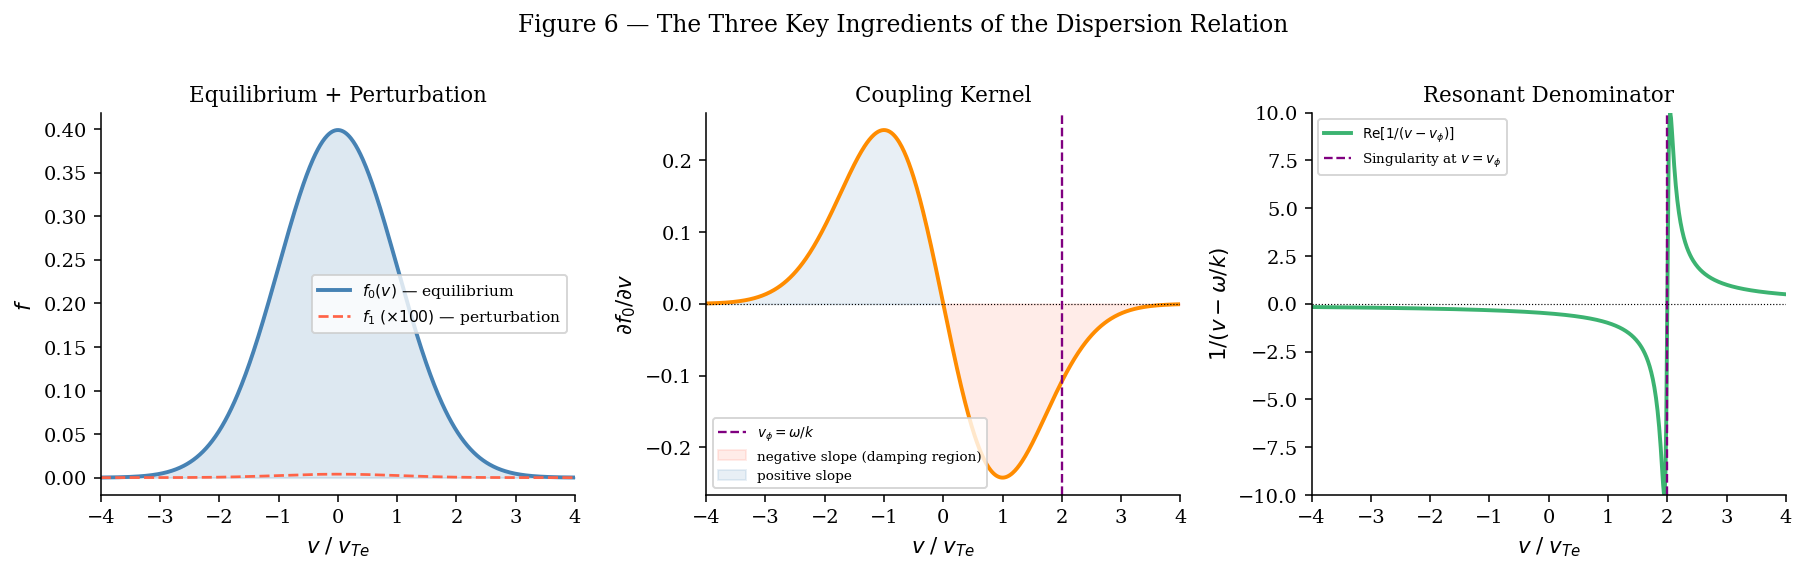

In [5]:
# ── Figure 6: Linearisation — equilibrium, perturbation, resonance kernel ──────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
v = np.linspace(-4, 4, 600)
vTe = 1.0
n0  = 1.0

f0    = (n0 / (np.sqrt(2*np.pi)*vTe)) * np.exp(-v**2 / (2*vTe**2))
f0_p  = 1.0e-2 * f0                      # f1 drawn at 1% of f0
df0dv = -(v / vTe**2) * f0
v_phi = 2.0                               # example phase velocity
denom = 1.0 / (v - v_phi + 0.05j)        # small imaginary shift to display

# --- Panel 1: f0 with f1 overlay ---
ax = axes[0]
ax.fill_between(v, f0, alpha=0.18, color='steelblue')
ax.plot(v, f0,   color='steelblue', lw=2,   label=r'$f_0(v)$ — equilibrium')
ax.plot(v, f0_p, color='tomato',    lw=1.4, ls='--', label=r'$f_1 \;(\times 100)$ — perturbation')
ax.set_xlabel(r'$v \;/\; v_{Te}$'); ax.set_ylabel(r'$f$')
ax.set_title('Equilibrium + Perturbation')
ax.legend(fontsize=8); ax.set_xlim(-4,4)

# --- Panel 2: df0/dv (coupling kernel) ---
ax = axes[1]
ax.plot(v, df0dv, color='darkorange', lw=2)
ax.axhline(0, color='k', lw=0.6, ls=':')
ax.axvline(v_phi, color='purple', lw=1.2, ls='--', label=r'$v_\phi = \omega/k$')
ax.fill_between(v, df0dv, where=(v>0), alpha=0.12, color='tomato',    label='negative slope (damping region)')
ax.fill_between(v, df0dv, where=(v<0), alpha=0.12, color='steelblue', label='positive slope')
ax.set_xlabel(r'$v \;/\; v_{Te}$'); ax.set_ylabel(r'$\partial f_0/\partial v$')
ax.set_title('Coupling Kernel')
ax.legend(fontsize=7); ax.set_xlim(-4,4)

# --- Panel 3: resonant denominator 1/(v - v_phi) ---
ax = axes[2]
ax.plot(v, denom.real, color='mediumseagreen', lw=2, label=r'$\mathrm{Re}[1/(v-v_\phi)]$')
ax.axvline(v_phi, color='purple', lw=1.2, ls='--', label=r'Singularity at $v = v_\phi$')
ax.axhline(0, color='k', lw=0.6, ls=':')
ax.set_xlabel(r'$v \;/\; v_{Te}$'); ax.set_ylabel(r'$1/(v - \omega/k)$')
ax.set_title('Resonant Denominator')
ax.set_ylim(-10, 10); ax.legend(fontsize=7); ax.set_xlim(-4,4)

fig.suptitle('Figure 6 — The Three Key Ingredients of the Dispersion Relation', y=1.01)
plt.tight_layout()
plt.show()

---
<a id='6'></a>
## 6. Langmuir Waves, the Landau Prescription, and Collisionless Damping

Section 5 reduced the full kinetic description to a single algebraic condition — the electrostatic dispersion relation:

$$\varepsilon(k,\omega) \equiv 1 - \frac{\omega_{pe}^2}{k^2}\int_{-\infty}^{\infty}\frac{\partial\hat{f}_0/\partial v}{v - \omega/k}\,dv = 0. \tag{5.17}$$

Its vanishing signals a collective resonance, but the condition is mathematically incomplete: the integral diverges at $v = \omega/k$, where the phase velocity coincides with the speed of some electrons. Treating $\omega$ as purely real — as a normal-mode analysis implicitly does — makes this singularity unavoidable.

Section 6 resolves it systematically. The singularity is not a defect but a **physical message**: it marks where wave-particle energy exchange occurs. Extracting it correctly yields both the wave frequency and its damping rate. The section proceeds in three stages:

- **6.1** treats the integral as an initial-value problem and derives the **Landau Prescription** — the contour deformation that renders the singular integral well-defined.
- **6.2** uses $\text{Re}[\varepsilon] = 0$ to derive the **Bohm–Gross dispersion relation** $\omega_r^2 = \omega_{pe}^2 + 3k^2v_{Te}^2$.
- **6.3** uses $\text{Im}[\varepsilon] = 0$ to derive the **Landau damping rate** $\gamma(k)$.

---

## 6.1 The Landau Prescription: Resolving the Resonant Denominator

### 6.1.1 Background: Why the Singularity is Not a Failure

The phase velocity $v_\phi = \omega/k$ is the wave crest speed. A particle at exactly $v_\phi$ sees a static electric field — locked in resonance, it experiences a sustained, non-oscillating force that can do continuous work, exchanging energy between wave and particle. This is precisely what the singularity at $v = \omega/k$ encodes. The mathematical challenge is therefore not to remove it, but to integrate through it faithfully.

### 6.1.2 The Root Cause: The Normal Mode Assumption

The singularity originates in Section 5's implicit assumption that $\omega$ is real — treating the wave as an eternal, constant-amplitude oscillation since $t = -\infty$. In reality, the wave is turned on at $t = 0$: an **initial value problem**. Landau (1946) recognised that framing it correctly as such resolves the singularity.

The appropriate tool is the **Laplace transform** in time. Its variable $s = \gamma + i\omega_r$ carries a positive real part during inversion, so $\omega = \omega_r + i\gamma$ with $\gamma > 0$ initially. The singularity $v = \omega/k$ is thereby displaced off the real $v$-axis into the upper half of the complex plane, and the real-axis integration contour passes *below* it without touching it — the integral is well-defined. The physical question becomes: what happens as $\gamma \to 0^+$, when the singularity descends toward the real axis? Tracking the integral through this limit is the Landau prescription.

### 6.1.3 The Landau Contour

Let $a = \omega_r/k$ be the real phase velocity. For $\gamma > 0$, the singularity sits at $v = a + i(\gamma/k)$, above the real axis. As $\gamma \to 0^+$, the singularity approaches the real axis from above. To preserve **causality** — the plasma responds *after* the wave starts, not before — the contour must be deformed to pass **below** the singularity:

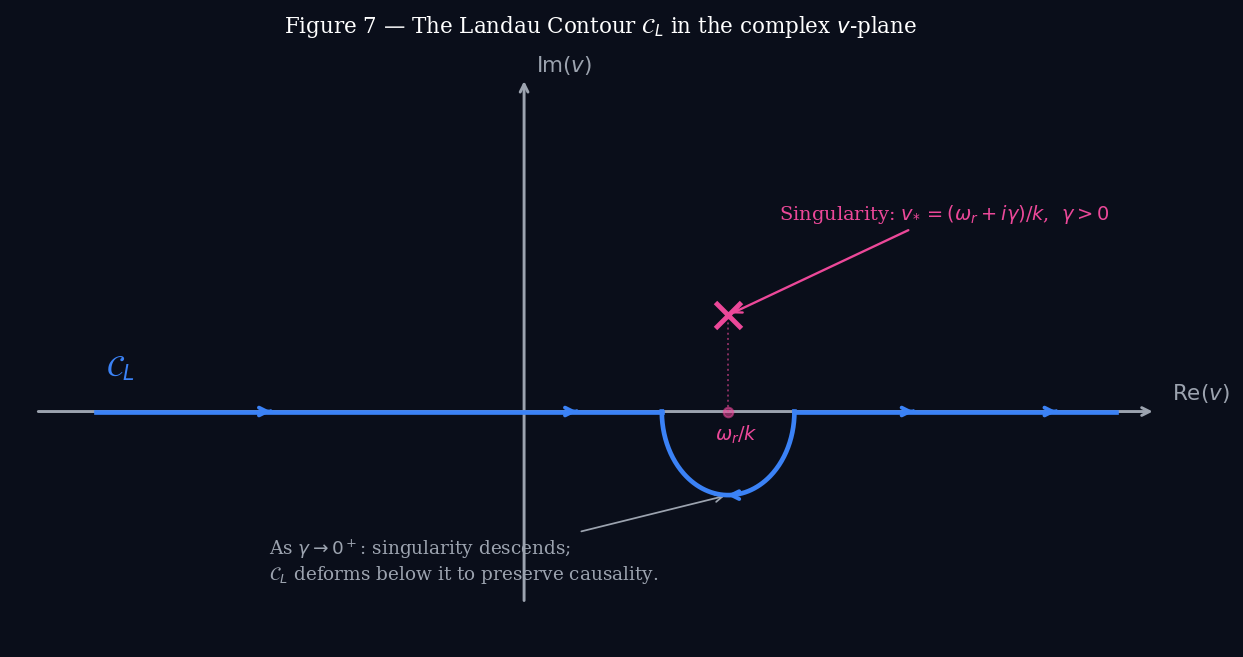

In [6]:
# ── Figure 7: Landau Contour in the Complex v-Plane ─────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.set_facecolor("#0a0e1a")
fig.patch.set_facecolor("#0a0e1a")
ax.set_xlim(-5.0, 6.5)
ax.set_ylim(-1.8, 2.8)
ax.set_xticks([])
ax.set_yticks([])
ax.spines[:].set_visible(False)

# ── Axes arrows ────────────────────────────────────────────────────────────────
ax.annotate("", xy=(6.2, 0), xytext=(-4.8, 0),
            arrowprops=dict(arrowstyle="->", color="#9ca3af", lw=1.5))
ax.annotate("", xy=(0, 2.6), xytext=(0, -1.5),
            arrowprops=dict(arrowstyle="->", color="#9ca3af", lw=1.5))
ax.text(6.35, 0.06, r"$\mathrm{Re}(v)$", color="#9ca3af", fontsize=11, va="bottom")
ax.text(0.12, 2.65, r"$\mathrm{Im}(v)$", color="#9ca3af", fontsize=11)

# ── Singularity ────────────────────────────────────────────────────────────────
v_phi, eps_sing = 2.0, 0.75
ax.plot(v_phi, eps_sing, "x", ms=13, mew=2.5, color="#ec4899", zorder=6)
ax.annotate(
    r"Singularity: $v_{\!*} = (\omega_r + i\gamma)/k$,  $\gamma > 0$",
    xy=(v_phi, eps_sing), xytext=(v_phi + 0.5, eps_sing + 0.75),
    color="#ec4899", fontsize=10, ha="left",
    arrowprops=dict(arrowstyle="->", color="#ec4899", lw=1.2),
)

# ── Landau contour (straight–dip–straight) ────────────────────────────────────
r_arc = 0.65
v_left  = np.linspace(-4.2, v_phi - r_arc, 300)
v_right = np.linspace(v_phi + r_arc, 5.8, 300)
theta   = np.linspace(0.0, -np.pi, 200)
v_arc   = v_phi + r_arc * np.cos(theta)
im_arc  =         r_arc * np.sin(theta)

contour_color = "#3b82f6"
lw = 2.4
ax.plot(v_left,  np.zeros_like(v_left),   color=contour_color, lw=lw, zorder=4)
ax.plot(v_arc,   im_arc,                  color=contour_color, lw=lw, zorder=4)
ax.plot(v_right, np.zeros_like(v_right),  color=contour_color, lw=lw, zorder=4)

# Direction arrows on contour
for xp in [-2.5, 0.5, 3.8, 5.2]:
    ax.annotate("", xy=(xp + 0.02, 0), xytext=(xp - 0.02, 0),
                arrowprops=dict(arrowstyle="->", color=contour_color, lw=2.0))
# Arrow at arc bottom
ax.annotate("", xy=(v_phi - 0.01, -r_arc), xytext=(v_phi + 0.01, -r_arc),
            arrowprops=dict(arrowstyle="->", color=contour_color, lw=2.0))

# ── Dashed projection of singularity onto real axis ────────────────────────────
ax.plot([v_phi, v_phi], [0.0, eps_sing], color="#ec4899",
        lw=1.0, ls=":", alpha=0.55, zorder=3)
ax.plot(v_phi, 0, "o", ms=5, color="#ec4899", alpha=0.55, zorder=5)
ax.text(v_phi + 0.08, -0.22, r"$\omega_r / k$",
        color="#ec4899", fontsize=10, ha="center")

# ── Labels ─────────────────────────────────────────────────────────────────────
ax.text(-4.1, 0.28, r"$\mathcal{C}_L$",
        color=contour_color, fontsize=15, fontweight="bold")
ax.annotate(
    r"As $\gamma \to 0^+$: singularity descends;" "\n"
    r"$\mathcal{C}_L$ deforms below it to preserve causality.",
    xy=(v_phi, -r_arc), xytext=(-2.5, -1.3),
    color="#9ca3af", fontsize=9.5, ha="left",
    arrowprops=dict(arrowstyle="->", color="#9ca3af", lw=0.9),
)

ax.set_title(
    r"Figure 7 — The Landau Contour $\mathcal{C}_L$ in the complex $v$-plane",
    color="white", fontsize=11, pad=10,
)
plt.tight_layout()
plt.show()


Figure 7 above is the **Landau contour** $\mathcal{C}_L$. Any other choice yields an acausal solution; causality therefore uniquely fixes the integration path.

### 6.1.4 Derivation of the Plemelj–Sokhotski Identity

We evaluate the limiting integral:

$$I = \lim_{\varepsilon \to 0^+} \int_{-\infty}^{\infty} \frac{g(v)}{v - a - i\varepsilon}\,dv,$$

where $a = \omega_r/k$, $\varepsilon = \gamma/k > 0$, and $g(v) = \partial\hat{f}_0/\partial v$ is smooth and rapidly decaying.

**Step 1: Rationalise.**

$$\frac{1}{v - a - i\varepsilon} = \frac{(v-a) + i\varepsilon}{(v-a)^2 + \varepsilon^2},$$

splitting $I$ into real and imaginary parts:

$$I = \int_{-\infty}^{\infty} g(v)\,\frac{v - a}{(v-a)^2 + \varepsilon^2}\,dv \;+\; i\varepsilon \int_{-\infty}^{\infty} g(v)\,\frac{1}{(v-a)^2 + \varepsilon^2}\,dv. \tag{6.1a}$$

**Step 2: Imaginary part as $\varepsilon \to 0^+$.**

The factor $\varepsilon/[(v-a)^2+\varepsilon^2]$ is a Lorentzian of width $\varepsilon$ centred at $v = a$; in the limit it concentrates into a Dirac delta:

$$\lim_{\varepsilon \to 0^+}\frac{\varepsilon}{(v-a)^2 + \varepsilon^2} = \pi\,\delta(v - a).$$

Therefore:

$$\lim_{\varepsilon \to 0^+} i\varepsilon \int_{-\infty}^{\infty} \frac{g(v)}{(v-a)^2 + \varepsilon^2}\,dv = i\pi\,g(a). \tag{6.1b}$$

**Step 3: Real part as $\varepsilon \to 0^+$.**

The factor $(v-a)/[(v-a)^2+\varepsilon^2]$ is odd about $v = a$; treating the singularity symmetrically yields the **Cauchy Principal Value**:

$$\lim_{\varepsilon \to 0^+}\int_{-\infty}^{\infty} g(v)\,\frac{v-a}{(v-a)^2 + \varepsilon^2}\,dv = \mathcal{P}\int_{-\infty}^{\infty}\frac{g(v)}{v - a}\,dv, \tag{6.1c}$$

$$\mathcal{P}\int_{-\infty}^{\infty}\frac{g(v)}{v - a}\,dv \equiv \lim_{\eta \to 0^+}\left[\int_{-\infty}^{a-\eta}\frac{g(v)}{v-a}\,dv + \int_{a+\eta}^{\infty}\frac{g(v)}{v-a}\,dv\right].$$

The symmetric exclusion ensures that particles slightly slower and faster than the wave contribute equal and opposite non-resonant responses, keeping the integral finite.

**Step 4: The Plemelj–Sokhotski identity.**

$$\boxed{\lim_{\varepsilon \to 0^+}\int_{-\infty}^{\infty}\frac{\partial\hat{f}_0/\partial v}{v - \omega_r/k - i\varepsilon}\,dv = \mathcal{P}\int_{-\infty}^{\infty}\frac{\partial\hat{f}_0/\partial v}{v - \omega_r/k}\,dv + i\pi\left.\frac{\partial\hat{f}_0}{\partial v}\right|_{v=\omega_r/k}.} \tag{6.2}$$

**Variable anatomy:**
- $\mathcal{P}\int$ — the Cauchy Principal Value; the **bulk, non-resonant** response of all particles away from the wave speed. Sets the wave frequency.
- $i\pi\,\partial\hat{f}_0/\partial v|_{v=\omega_r/k}$ — the **residue term**; the singular contribution of resonant particles. The factor $i$ means this term governs amplitude growth or decay, not frequency.

### 6.1.5 The Two Physical Parts

**Part A — The Principal Value (Bulk Response).** Non-resonant particles experience an oscillating force averaging to zero over one wave period; they exchange no net energy with the wave. Instead they supply collective electromagnetic inertia and a restoring force — the "mass and spring" that determine oscillation frequency.

**Part B — The Residue (Resonant Particles).** Particles at $v \approx v_\phi$ see a nearly static force and can exchange energy continuously. The slope $\partial\hat{f}_0/\partial v$ at $v_\phi$ determines the direction:
- $\partial\hat{f}_0/\partial v < 0$ (more slow than fast, as in a Maxwellian): wave loses energy → **Landau Damping**.
- $\partial\hat{f}_0/\partial v > 0$ (more fast than slow, as in a beam): wave gains energy → **kinetic instability**.

Substituting (6.2) into (5.17), the dielectric function splits cleanly:

$$\varepsilon(k, \omega_r) = \varepsilon_R(k, \omega_r) + i\,\varepsilon_I(k, \omega_r) = 0, \tag{6.3}$$

$$\varepsilon_R = 1 - \frac{\omega_{pe}^2}{k^2}\,\mathcal{P}\int_{-\infty}^{\infty}\frac{\partial\hat{f}_0/\partial v}{v - \omega_r/k}\,dv, \tag{6.4}$$

$$\varepsilon_I = -\frac{\pi\,\omega_{pe}^2}{k^2}\left.\frac{\partial\hat{f}_0}{\partial v}\right|_{v=\omega_r/k}. \tag{6.5}$$

These two equations — one real, one imaginary — together determine $\omega_r$ and $\gamma$, extracted in the next two subsections.

---

## 6.2 The Bohm–Gross Dispersion Relation

### 6.2.1 Background: Why We Need a Long-Wavelength Expansion

The condition $\varepsilon_R(k, \omega_r) = 0$ is a transcendental equation with no closed form for arbitrary $\omega_r/k$. Progress requires identifying the physically relevant regime. Langmuir waves are **fast**: their phase velocity $v_\phi = \omega_r/k \gg v_{Te}$, placing the resonance deep in the tail of the Maxwellian where exponentially few particles reside. Equivalently, the perturbation wavelength $\lambda = 2\pi/k$ greatly exceeds the Debye screening length $\lambda_D = v_{Te}/\omega_{pe}$, so $k\lambda_D \ll 1$. Since $kv_{Te}/\omega_r \sim k\lambda_D \ll 1$, most thermal electrons move much slower than the wave, enabling a **Taylor expansion** of the integrand in powers of $v/v_\phi \ll 1$.

### 6.2.2 Step-by-Step Derivation

**Step 1: Taylor-expand the resonant denominator.**

$$\frac{1}{v - \omega_r/k} = -\frac{k}{\omega_r}\cdot\frac{1}{1 - kv/\omega_r} = -\frac{k}{\omega_r}\left[1 + \frac{kv}{\omega_r} + \left(\frac{kv}{\omega_r}\right)^2 + \left(\frac{kv}{\omega_r}\right)^3 + \cdots\right]. \tag{6.6}$$

**Step 2: Substitute into the principal value integral.**

$$\mathcal{P}\int_{-\infty}^{\infty}\frac{\partial\hat{f}_0/\partial v}{v - \omega_r/k}\,dv = -\frac{k}{\omega_r}\int_{-\infty}^{\infty}\frac{\partial\hat{f}_0}{\partial v}\left[1 + \frac{kv}{\omega_r} + \frac{k^2 v^2}{\omega_r^2} + \frac{k^3 v^3}{\omega_r^3} + \cdots\right]dv. \tag{6.7}$$

Each term is evaluated by integration by parts — $\int(\partial\hat{f}_0/\partial v)\cdot v^n\,dv = -n\int\hat{f}_0\,v^{n-1}\,dv$ (boundary terms vanish since $\hat{f}_0$ decays faster than any power of $v$):

- $n = 0$: $\int\partial\hat{f}_0/\partial v\,dv = 0$.  
- $n = 1$: $\int(\partial\hat{f}_0/\partial v)\cdot v\,dv = -1$ (normalisation).  
- $n = 2$: $\int(\partial\hat{f}_0/\partial v)\cdot v^2\,dv = 0$ (zero-drift Maxwellian).  
- $n = 3$: $\int(\partial\hat{f}_0/\partial v)\cdot v^3\,dv = -3v_{Te}^2$ (second moment).

**Step 3: Assemble the expansion.**

$$\mathcal{P}\int\frac{\partial\hat{f}_0/\partial v}{v - \omega_r/k}\,dv = \frac{k^2}{\omega_r^2}\left[1 + \frac{3k^2 v_{Te}^2}{\omega_r^2} + \cdots\right]. \tag{6.8}$$

**Step 4: Substitute into $\varepsilon_R = 0$.**

$$1 - \frac{\omega_{pe}^2}{\omega_r^2}\left[1 + \frac{3k^2 v_{Te}^2}{\omega_r^2}\right] = 0 \quad\Longrightarrow\quad \omega_r^2 = \omega_{pe}^2\left[1 + \frac{3k^2 v_{Te}^2}{\omega_r^2}\right]. \tag{6.9}$$

**Step 5: Iterate to lowest order in $k\lambda_D$.**

At leading order $\omega_r^2 \approx \omega_{pe}^2$; substituting back into the correction (already of order $k^2\lambda_D^2$):

$$\boxed{\omega_r^2 = \omega_{pe}^2 + 3k^2 v_{Te}^2 = \omega_{pe}^2\!\left(1 + 3k^2\lambda_D^2\right).} \tag{6.10}$$

This is the **Bohm–Gross Dispersion Relation**.

### 6.2.3 Variable Anatomy and Physical Interpretation

| Symbol | Meaning | Units |
|--------|---------|-------|
| $\omega_r$ | Real oscillation frequency | $\text{rad s}^{-1}$ |
| $\omega_{pe} = \sqrt{n_0 e^2/m_e\epsilon_0}$ | Electron plasma frequency — fundamental resonant frequency of the electron gas | $\text{rad s}^{-1}$ |
| $k$ | Wavenumber ($= 2\pi/\lambda$) | $\text{m}^{-1}$ |
| $v_{Te} = \sqrt{k_B T_e/m_e}$ | Electron thermal velocity | $\text{m s}^{-1}$ |
| $\lambda_D = v_{Te}/\omega_{pe}$ | Debye length — natural plasma length scale | $\text{m}$ |

**Physical interpretation:**

- $\omega_{pe}^2$: the **cold-plasma term** — the electrostatic restoring force pulling displaced electrons back to the ion background. Density alone determines it; even a zero-temperature plasma oscillates at $\omega_{pe}$.

- $3k^2 v_{Te}^2$: the **thermal correction (Bohm–Gross term)** — the additional stiffness from electron pressure. Shorter wavelengths produce sharper compressions, steeper pressure gradients, and stronger restoring forces. The coefficient 3 is the adiabatic index for a 1D electron gas ($\gamma_{\rm ad} = 3$), consistent with compression along the propagation direction only.

Together, these terms show that Langmuir waves are **dispersive**: $\omega_r/k = (\omega_{pe}/k)\sqrt{1 + 3k^2\lambda_D^2}$ increases with $k$, so short-wavelength waves travel faster than long-wavelength ones.

### 6.2.4 Transition: From Frequency to Lifetime

The Bohm–Gross relation answers "at what frequency does the plasma oscillate?" but is silent on how long the oscillation survives — it assumed a real $\omega$ and found only $\omega_r$. The Landau Prescription revealed that $\omega$ is generically complex, with an imaginary part $\gamma$ governing growth or decay. To find $\gamma$, we turn to the imaginary dielectric condition (6.5).

---

## 6.3 The Landau Damping Rate

### 6.3.1 Background: Why Waves Die Without Collisions

Classical fluid theory predicts undamped propagation in an inviscid, non-resistive medium — consistent with the real Bohm–Gross frequency. Yet simulations and laboratory experiments show that Langmuir waves decay. The mechanism is *collisionless*, arising purely from wave-particle kinematics.

In a Maxwellian, $\partial f_0/\partial v < 0$ everywhere: there are always more slow particles than fast ones. A particle slightly slower than $v_\phi$ is overtaken by a wave crest and accelerated — it gains energy from the wave. A particle slightly faster outruns the crest and decelerates — it loses energy to the wave. Because more slow particles than fast ones populate the neighbourhood of $v_\phi$, the net energy flow is **from wave to particles**: the wave decays. This is Landau Damping — organised wave energy converted into thermal motion of resonant particles through coherent wave-particle interaction, without a single collision.

### 6.3.2 The "Small $\gamma$" Approach (Linearisation in the Damping Rate)

The Bohm–Gross analysis established that $|\gamma| \ll \omega_r$: the wave oscillates many times before decaying. We exploit this by treating $\gamma$ as a small perturbation to $\omega_r$.

**Step 1: Write $\omega = \omega_r + i\gamma$.**

$$\varepsilon(k, \omega_r + i\gamma) = \varepsilon_R(k, \omega_r + i\gamma) + i\,\varepsilon_I(k, \omega_r + i\gamma) = 0. \tag{6.11}$$

**Step 2: Taylor-expand $\varepsilon$ around $\omega_r$.**

$$\varepsilon(k, \omega_r + i\gamma) \approx \varepsilon(k, \omega_r) + i\gamma\left.\frac{\partial\varepsilon}{\partial\omega}\right|_{\omega_r} = 0. \tag{6.12}$$

At $\omega = \omega_r$, $\varepsilon_R(k, \omega_r) = 0$ by construction, so $\varepsilon(k, \omega_r) = i\,\varepsilon_I(k, \omega_r)$. Since $\varepsilon_I$ is exponentially small in the long-wavelength limit, the derivative is dominated by its real part:

$$\left.\frac{\partial\varepsilon}{\partial\omega}\right|_{\omega_r} \approx \left.\frac{\partial\varepsilon_R}{\partial\omega}\right|_{\omega_r}. \tag{6.14}$$

**Step 3: Solve for $\gamma$.**

$$\boxed{\gamma = -\frac{\varepsilon_I}{\partial\varepsilon_R/\partial\omega}\Bigg|_{\omega = \omega_r}.} \tag{6.15}$$

The numerator captures the resonant particle contribution; the denominator quantifies the wave's stored energy — a steeper $\partial\varepsilon_R/\partial\omega$ means more energy stored per unit field amplitude, making the wave harder to damp.

### 6.3.3 Part A — The Numerator: Evaluating $\varepsilon_I$

From (6.5):

$$\varepsilon_I = -\frac{\pi\,\omega_{pe}^2}{k^2}\left.\frac{\partial\hat{f}_0}{\partial v}\right|_{v=\omega_r/k}. \tag{6.16}$$

The equilibrium is Maxwellian — the **maximum entropy** distribution, uniquely determined by density $n_0$ and temperature $T_e$:

$$\hat{f}_0(v) = \frac{1}{\sqrt{2\pi}\,v_{Te}}\exp\!\left(-\frac{v^2}{2v_{Te}^2}\right), \qquad \frac{\partial\hat{f}_0}{\partial v} = -\frac{v}{v_{Te}^2}\,\hat{f}_0(v). \tag{6.18}$$

The slope is negative for $v > 0$ and zero at $v = 0$ (the peak). Evaluating at $v = \omega_r/k$:

$$\left.\frac{\partial\hat{f}_0}{\partial v}\right|_{v=\omega_r/k} = -\frac{\omega_r}{k\,v_{Te}^2}\cdot\frac{1}{\sqrt{2\pi}\,v_{Te}}\exp\!\left(-\frac{\omega_r^2}{2k^2 v_{Te}^2}\right). \tag{6.19}$$

Substituting into (6.16):

$$\varepsilon_I = \sqrt{\frac{\pi}{2}}\cdot\frac{\omega_{pe}^2\,\omega_r}{k^3\,v_{Te}^3}\exp\!\left(-\frac{\omega_r^2}{2k^2v_{Te}^2}\right). \tag{6.20}$$

### 6.3.4 Part B — The Denominator: Evaluating $\partial\varepsilon_R/\partial\omega$

Using the cold-plasma approximation $\varepsilon_R \approx 1 - \omega_{pe}^2/\omega^2$ — valid here because thermal corrections to $\varepsilon_R$ are of order $k^2\lambda_D^2$, while $\gamma$ is exponentially smaller:

$$\frac{\partial\varepsilon_R}{\partial\omega} = \frac{2\omega_{pe}^2}{\omega^3} \quad\Longrightarrow\quad \left.\frac{\partial\varepsilon_R}{\partial\omega}\right|_{\omega_r \approx \omega_{pe}} = \frac{2}{\omega_{pe}}. \tag{6.22-6.23}$$

### 6.3.5 Exponent Correction from Bohm–Gross

Inserting $\omega_r^2 = \omega_{pe}^2 + 3k^2v_{Te}^2$ (6.10) into the exponential argument:

$$\frac{\omega_r^2}{2k^2 v_{Te}^2} = \frac{1}{2k^2\lambda_D^2} + \frac{3}{2}. \tag{6.24}$$

The extra $3/2$ arises from the thermal correction to the wave frequency — it pushes the resonance deeper into the Maxwellian tail, making damping exponentially *weaker*:

$$\exp\!\left(-\frac{\omega_r^2}{2k^2 v_{Te}^2}\right) = \exp\!\left(-\frac{1}{2k^2\lambda_D^2} - \frac{3}{2}\right). \tag{6.25}$$

### 6.3.6 Assembling the Landau Damping Rate

Substituting (6.20), (6.23), and (6.25) into (6.15) with $\omega_r \approx \omega_{pe}$ and $v_{Te}^3 = \omega_{pe}^3\lambda_D^3$:

$$\boxed{\gamma = -\sqrt{\frac{\pi}{8}}\,\cdot\,\frac{\omega_{pe}}{k^3\lambda_D^3}\,\cdot\,\exp\!\left(-\frac{1}{2k^2\lambda_D^2} - \frac{3}{2}\right).} \tag{6.26}$$

### 6.3.7 Variable Anatomy and Physical Interpretation

| Symbol | Meaning | Effect on $\gamma$ |
|--------|---------|-------------------|
| $\gamma < 0$ | Negative imaginary frequency → wave decays as $e^{\gamma t}$ | — |
| $\omega_{pe}$ | Plasma frequency — fundamental timescale | $|\gamma| \propto \omega_{pe}$: denser plasma damps faster |
| $k^3\lambda_D^3$ | Dimensionless wavenumber cubed | $|\gamma| \propto 1/k^3\lambda_D^3$: long-wavelength waves damp slowly |
| $\exp(-1/2k^2\lambda_D^2)$ | Exponential suppression | **Dominant factor**: damping is exponentially weak at long wavelengths |
| $\exp(-3/2)$ | Bohm–Gross correction | Moves resonance deeper into the tail, reducing $|\gamma|$ by a fixed factor |

The exponential dependence is the defining feature of (6.26). As $k\lambda_D \to 0$, $\exp(-1/2k^2\lambda_D^2) \to 0$ faster than any power of $k$: long-wavelength waves are essentially undamped because $v_\phi \gg v_{Te}$ leaves exponentially few thermal particles in resonance. Damping is not a power law in $k\lambda_D$ but an exponential — a direct consequence of the Maxwellian's tail.

### 6.3.8 Why This Result is Non-perturbative

The factor $\exp(-1/2k^2\lambda_D^2)$ in (6.26) **cannot be reproduced by any finite-order perturbation theory** in $k\lambda_D$: Taylor series never generate exponentials. This is why Landau damping was overlooked for so long and why Landau's initial-value approach was revolutionary — the result is intrinsically non-perturbative, arising from the analytic structure of $\varepsilon(k,\omega)$ in the complex frequency plane.

---

## Summary

The three results of Section 6 form a single integrated argument:

| Subsection | Result | Physical Role |
|-----------|--------|---------------|
| 6.1 — Landau Prescription | Plemelj–Sokhotski: $\int \to \mathcal{P}\int + i\pi g(v_\phi)$ | Separates resonant (energy-exchanging) and bulk (frequency-setting) contributions |
| 6.2 — Bohm–Gross Relation | $\omega_r^2 = \omega_{pe}^2 + 3k^2 v_{Te}^2$ | Determines the real oscillation frequency — the "pitch" of the Langmuir wave |
| 6.3 — Landau Damping Rate | $\gamma = -\sqrt{\pi/8}\,(\omega_{pe}/k^3\lambda_D^3)\,e^{-1/2k^2\lambda_D^2 - 3/2}$ | Determines the wave lifetime — how fast the oscillation fades |

**The logical thread is sequential:** Section 5 gave us $\varepsilon(k,\omega) = 0$ but could not evaluate its singular integral $\longrightarrow$ Section 6.1 (Landau Prescription) resolved the singularity, splitting $\varepsilon$ into a real part (bulk response) and an imaginary part (resonant particles) $\longrightarrow$ Section 6.2 (Bohm–Gross) solved $\text{Re}[\varepsilon] = 0$ via a long-wavelength expansion to find $\omega_r(k)$ $\longrightarrow$ Section 6.3 (Landau Damping) used $\text{Im}[\varepsilon]$ and $\partial\varepsilon_R/\partial\omega$ to find $\gamma(k)$, completing the full complex dispersion relation $\omega(k) = \omega_r(k) + i\gamma(k)$ — a prediction directly testable against the Vlasov–Poisson simulation that follows.

---
<a id='7'></a>
## 7. From Theory to Simulation

The preceding sections built the Vlasov–Poisson system analytically: phase-space incompressibility (Section 3), self-consistent closure (Section 4), linearisation and the dispersion relation (Section 5), and exact damping rates via the Landau prescription (Section 6). Each result is exact — but only within the linear regime.

### 7.1 Where Linear Theory Ends

Linearisation assumes $|f_1| \ll f_0$. When this breaks, three phenomena emerge that no closed-form analysis captures:

- **Particle trapping.** Resonant particles with $v \approx \omega/k$ are captured in wave troughs and begin to bounce, forming the phase-space vortices known as BGK modes or Schamel holes.
- **Nonlinear frequency shift.** The bounce frequency of trapped particles modifies $\omega_r$, shifting the wave off the Bohm–Gross curve.
- **Saturation and mode coupling.** Energy cascades from the driven mode into harmonics; damping gives way to a nonlinear saturated state.

These are not corrections to linear theory — they are qualitatively new physics. Simulation is the only recourse.

### 7.2 The Characteristic Structure as a Numerical Principle

Section 3 showed that the Vlasov equation is a statement about characteristics:

$$\frac{Df}{Dt}\bigg|_{\rm orbit} = 0.$$

This is simultaneously a conservation theorem and a recipe for discretisation. The semi-Lagrangian method exploits it directly: instead of differencing the left-hand side, one traces characteristics backward in time and interpolates:

$$f^{n+1}(x_i, v_j) = f^n\!\left(x_i - v_j\,\Delta t,\; v_j + \frac{e}{m}E\,\Delta t\right). \tag{7.2}$$

The scheme is noise-free and unconditionally stable for linear advection, making it the natural choice for resolving Landau damping — where statistical noise from particle methods would mask the very signal being measured.

### 7.3 Theoretical Results as Simulation Targets

Every analytical result from earlier sections serves a concrete role in the numerical workflow:

| Theoretical result | Role in simulation |
|---|---|
| $\Lambda = n_0\lambda_D^3 \gg 1$ (Section 0) | Justifies mean-field closure; sets physical parameter regime |
| Maxwellian $f_0$ (Section 1) | Initial condition; moments $n,u,T,q$ are the diagnostic output |
| $Df/Dt = 0$ along orbits (Section 3) | Basis of the semi-Lagrangian advection step |
| Vlasov–Poisson coupling (Section 4) | Defines the self-consistent $E[f]$ loop closed at every timestep |
| $\omega_r(k) = \sqrt{\omega_{pe}^2 + 3k^2v_{Te}^2}$ (Section 6) | Target oscillation frequency to recover from field data |
| $\gamma(k)$ from Landau prescription (Section 6) | Target decay rate; measured by exponential fit to $\|E(t)\|$ |
| $N,\,W = \mathrm{const.}$ | Sanity checks at every timestep; failure signals scheme error |

---
<a id='8'></a>
## Appendix

---
### Variables Notations for Preceding Sections
**Notation and Dimensional Bridge: Sections 5–6 relative to Sections 0–4**

Five coordinated simplifications are made entering Section 5, each exact under the plane-wave, single-species geometry appropriate for Langmuir oscillations. They are collected here so that every symbol in Sections 5–6 maps unambiguously onto the general framework above.


---

*1. Why 1D? The Plane-Wave Reduction.*

Sections 0–4 work with the full 3D electrostatic Vlasov equation (Section 3, Section 4.2):

$$
\frac{\partial f_e}{\partial t}
+\mathbf{v}\cdot\nabla_{\mathbf{x}}f_e
-\frac{e}{m_e}\mathbf{E}\cdot\nabla_{\mathbf{v}}f_e=0.
\tag{$\star$}
$$

Langmuir waves are longitudinal electrostatic plane waves: the perturbation propagates along a single direction, here $\hat{x}$, so that $\partial/\partial y = \partial/\partial z = 0$ and $E_y = E_z = 0$. Under this assumption ($\star$) reduces component-by-component to

$$
\frac{\partial f}{\partial t}
+v_x\frac{\partial f}{\partial x}
-\frac{e}{m_e}E_x\frac{\partial f}{\partial v_x}=0.
$$

Renaming $v_x\to v$ and $E_x\to E$ gives the 1D scalar form employed throughout Sections 5–6. *The two equations are exactly equivalent under the plane-wave assumption*; no physics is discarded.

---

*2. Why $\partial f/\partial v$ instead of $\nabla_{\mathbf{v}} f_e$?*

In the 3D system (Sections 0–4), the velocity-space coupling appears as the vector dot product $\mathbf{E}\cdot\nabla_{\mathbf{v}}f_e$. In the 1D plane-wave geometry, only the $x$-component survives:

$$
\mathbf{E}\cdot\nabla_{\mathbf{v}}f_e
\;\xrightarrow{\text{1D}\;\hat{x}\text{-geometry}}\;
E_x\,\frac{\partial f}{\partial v_x}
\;\equiv\;
E\,\frac{\partial f}{\partial v}.
$$

The vector gradient $\nabla_{\mathbf{v}}$ therefore collapses to the scalar partial derivative $\partial/\partial v$. This is not an approximation — it is an exact consequence of the plane-wave symmetry.

---

*3. $f_e \to f$: Dropping the Electron Subscript.*

Section 4 explicitly labels the electron distribution $f_e$ to distinguish it from a possible ion distribution (Assumption A5 introduces the single-species reduction). In Sections 5–6, only electrons are tracked — ions remain a static background — so the subscript $e$ is dropped for notational brevity:

$$
f \equiv f_e \qquad (\text{Sections 5–6 only; single-species electron distribution}).
$$

Likewise, the perturbation notation changes from $\delta f$ (Sections 4.4–4.6) to $f_1$ (Sections 5), following standard linearisation convention:

$$
f_1\equiv\delta f,\qquad \phi_1\equiv\delta\phi,\qquad E_1\equiv\delta E.
$$

---

*4. The $\mathbf{r}\to\mathbf{x}\to x$ Notational Chain.*

- Sections 0–3 write the 3D position as $\mathbf{r}$, the standard notation in general kinetic theory.
- Section 4 switches to $\mathbf{x}$ — an equally standard choice prevalent in plasma kinetic texts (e.g. Nicholson, Krall & Trivelpiece). Both denote the same 3D position vector; the change is purely conventional.
- Sections 5–6 specialize further to the plane-wave geometry: $\mathbf{x}\to x$, where $x$ is the *scalar* coordinate along $\hat{x}$. Consequently $\nabla_{\mathbf{x}}\to\partial/\partial x$.

---

*5. The 1D Maxwellian as a Marginal of the 3D Maxwellian.*

The 3D Maxwellian of Sections 1 and 4 factorizes over Cartesian velocity components:

$$
f_0(\mathbf{v})
=n_0\!\left(\frac{m_e}{2\pi k_BT_e}\right)^{\!3/2}
\exp\!\left(-\frac{m_e|\mathbf{v}|^2}{2k_BT_e}\right)
=\underbrace{\frac{n_0}{\sqrt{2\pi}\,v_{Te}}
\exp\!\left(-\frac{v_x^2}{2v_{Te}^2}\right)}_{\equiv\,f_0(v)\text{ of Sections 5–6}}
\times
\frac{e^{-v_y^2/2v_{Te}^2}}{\sqrt{2\pi}\,v_{Te}}
\times
\frac{e^{-v_z^2/2v_{Te}^2}}{\sqrt{2\pi}\,v_{Te}}.
$$

Integrating over $v_y$ and $v_z$ yields precisely the 1D Maxwellian (5.2). No assumption beyond the plane-wave geometry is required.

---

*Complete symbol glossary for Sections 5–6:*

| Quantity | Sections 0–3 | Section 4 | Sections 5–6 |
|---|---|---|---|
| Spatial variable | $\mathbf{r}\in\mathbb{R}^3$ | $\mathbf{x}\in\mathbb{R}^3$ | $x\in\mathbb{R}$ (scalar along $\hat{x}$) |
| Velocity variable | $\mathbf{v}\in\mathbb{R}^3$ | $\mathbf{v}\in\mathbb{R}^3$ | $v\in\mathbb{R}$ ($\equiv v_x$) |
| Electric field | $\mathbf{E}\in\mathbb{R}^3$ | $\mathbf{E}\in\mathbb{R}^3$ | $E\in\mathbb{R}$ ($\equiv E_x$) |
| Velocity coupling | $\mathbf{E}\cdot\nabla_{\mathbf{v}}f_e$ | $\mathbf{E}\cdot\nabla_{\mathbf{v}}f_e$ | $E\,\partial f/\partial v$ |
| Electron distribution | $f_e(\mathbf{r},\mathbf{v},t)$, 3D | $f_e(\mathbf{x},\mathbf{v},t)$, 3D | $f(x,v,t)\equiv f_e$, 1D |
| Equilibrium dist. | $f_0(\mathbf{v})$, 3D Maxwellian | $f_0(\mathbf{v})$, 3D Maxwellian | $f_0(v)$, 1D marginal |
| Perturbation | $\delta f$ | $\delta f$ | $f_1$ ($\equiv\delta f$) |
| Thermal velocity | — | — | $v_{Te}=\sqrt{k_BT_e/m_e}$ |

## References

 [1] F. F. Chen, *Introduction to Plasma Physics and Controlled Fusion*, 3rd ed., Springer, 2016.

 [2] D. R. Nicholson, *Introduction to Plasma Theory*, Wiley, 1983.

 [3] N. A. Krall and A. W. Trivelpiece, *Principles of Plasma Physics*, McGraw-Hill, 1973.

 [4] T. H. Stix, *Waves in Plasmas*, American Institute of Physics, 1992.

 [5] C. K. Birdsall and A. B. Langdon, *Plasma Physics via Computer Simulation*, CRC Press, 2004.

 [6] M. W. Kunz, *Lecture Notes on Introduction to Plasma Astrophysics*, Princeton University.

 [7] W. W. Lee, *Vlasov-Poisson Equations; Particle Codes; Klimontovich Representation*, Princeton Plasma Physics Laboratory lecture notes.

 [8] T. Umeda, Y. Omura, P. H. Yoon, R. Gaelzer, and H. Matsumoto, *Harmonic Langmuir waves. III. Vlasov simulation*, Physics of Plasmas 10, 382, 2003.

 [9] E. Fijalkow, *A numerical solution to the Vlasov equation*, Computer Physics Communications 116, pp. 319–328, 1999.

 [10] S. Brunner, *Advanced Theory of Plasmas*, Ecole Polytechnique Fédérale de Lausanne (EPFL) lecture notes.

 [11] N. Barbour, W. Dorland, I. G. Abel, and M. Landreman, *Machine-learning Closure for Vlasov-Poisson Dynamics in Fourier-Hermite Space*, arXiv:2501.01234v1 [physics.plasm-ph], 2025.

 [12] A. Tavassoli, O. Chapurin, M. Jimenez, et al., *The role of noise in PIC and Vlasov simulations of the Buneman instability*, Physics of Plasmas 28, 122105, 2021.

 [13] A. S. Joglekar and M. C. Levy, *VlaPy: A Python package for Eulerian Vlasov-Poisson-Fokker-Planck Simulations*, Journal of Open Source Software, 5(53), 2182, 2020.

 [14] E. Camporeale, G. L. Delzanno, B. K. Bergen, and J. D. Moulton, *On the velocity space discretization for the Vlasov-Poisson system: comparison between Hermite spectral and Particle-in-Cell methods. Part 1: semi-implicit scheme*, arXiv:1311.2098v2 [physics.plasm-ph], 2013.

 [15] E. Camporeale, G. L. Delzanno, B. K. Bergen, and J. D. Moulton, *On the velocity space discretization for the Vlasov-Poisson system: comparison between Hermite spectral and Particle-in-Cell methods. Part 2: fully-implicit scheme*, arXiv:1312.4991v1 [physics.plasm-ph], 2013.

 [16] C. Tronci and E. Camporeale, *Neutral Vlasov kinetic theory of magnetized plasmas*, Physics of Plasmas 22, 020704, 2015.

 [17] J. Sedlmeir, *The Vlasov equation for multiple particle types*, Master’s Thesis, Ludwig-Maximilians-Universität München, 2018.

 [18] P. M. Bellan, *The Vlasov, two-fluid, and MHD models of plasma dynamics*, Fundamentals of Plasma Physics, Chapter 2, Cambridge University Press, 2006.

 [19] N. Crouseilles, T. Respaud, and E. Sonnendrücker, *A Forward semi-Lagrangian Method for the Numerical Solution of the Vlasov Equation*, INRIA Research Report No. 6727, 2008.

 [20] Z. Cai, R. Li, and Y. Wang, *Solving Vlasov Equations Using NRxx Method*, arXiv:1803.04634v1 [math.NA], 2018.

 [21] P. Constantin and H. Grayer II, *Radiative Vlasov-Maxwell Equations*, arXiv:2407.01429v1 [math.AP], 2024.

 [22] J. Wang, K. Li, and H. Huang, *Error estimation in the mean-field limit of kinetic flocking models with local alignments*, arXiv:2407.04387v1 [math.AP], 2024.

 [23] T. H. Chang, *Physics of Plasmas (Lecture Notes)*, National Tsing Hua University.

 [24] J. Luk, *The Vlasov-Poisson-Landau system in the weakly collisional regime*, Isaac Newton Institute Seminar, University of Cambridge, YouTube.

 [25] P. Pickl, *Rigorous Derivation of the Vlasov equation*, ICTP Seminar, YouTube.

 [26] J. D. Callen, *Vlasov Equation Properties*, Introduction to Plasma Physics, YouTube Lecture Series.